<a href="https://colab.research.google.com/github/suneetaramanathan/TrustNest/blob/main/TrustNest_Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install required libraries
!pip install scikit-learn pandas numpy matplotlib

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [ ]:
# Create fake hotel data
# This simulates normal hotel activity + some suspicious activity

np.random.seed(42)

# Normal activity — staff accessing guest records normally
normal_access = np.random.normal(loc=10, scale=2, size=200)

# Suspicious activity — someone accessing too many records
suspicious_access = np.random.normal(loc=50, scale=5, size=10)

# Combine all activity
all_activity = np.concatenate([normal_access, suspicious_access])

# Create a dataframe
df = pd.DataFrame({
    'records_accessed': all_activity,
    'hour_of_day': np.random.randint(0, 24, size=210)
})

print("Hotel data created!")
print(f"Total activities: {len(df)}")
print(f"Sample data:")
print(df.head(10))

Hotel data created!
Total activities: 210
Sample data:
   records_accessed  hour_of_day
0         10.993428           12
1          9.723471           19
2         11.295377            0
3         13.046060            7
4          9.531693           13
5          9.531726           15
6         13.158426           13
7         11.534869           11
8          9.061051           18
9         11.085120           22


In [ ]:
# Build the Anomaly Detection Model
model = IsolationForest(contamination=0.05, random_state=42)

# Train the model on hotel activity data
X = df[['records_accessed', 'hour_of_day']]
df['anomaly'] = model.fit_predict(X)

# -1 means suspicious, 1 means normal
df['status'] = df['anomaly'].map({1: 'NORMAL', -1: 'SUSPICIOUS'})

# Show results
normal = len(df[df['status'] == 'NORMAL'])
suspicious = len(df[df['status'] == 'SUSPICIOUS'])

print("=" * 40)
print("   TRUSTNEST SECURITY SCAN RESULTS")
print("=" * 40)
print(f"Total Activities Scanned: {len(df)}")
print(f"Normal Activities:        {normal} ✅")
print(f"Suspicious Activities:    {suspicious} 🚨")
print("=" * 40)

if suspicious > 0:
    print("\n⚠️  ALERT: Suspicious activity detected!")
    print("\nSuspicious records:")
    print(df[df['status'] == 'SUSPICIOUS'][['records_accessed', 'hour_of_day', 'status']].head(10))

   TRUSTNEST SECURITY SCAN RESULTS
Total Activities Scanned: 210
Normal Activities:        199 ✅
Suspicious Activities:    11 🚨

⚠️  ALERT: Suspicious activity detected!

Suspicious records:
     records_accessed  hour_of_day      status
125         14.380911            0  SUSPICIOUS
200         51.788937           11  SUSPICIOUS
201         52.803923           19  SUSPICIOUS
202         55.415256           20  SUSPICIOUS
203         55.269010            3  SUSPICIOUS
204         43.111653           20  SUSPICIOUS
205         45.310875           22  SUSPICIOUS
206         52.575176           15  SUSPICIOUS
207         52.568930            6  SUSPICIOUS
208         52.575238           12  SUSPICIOUS


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


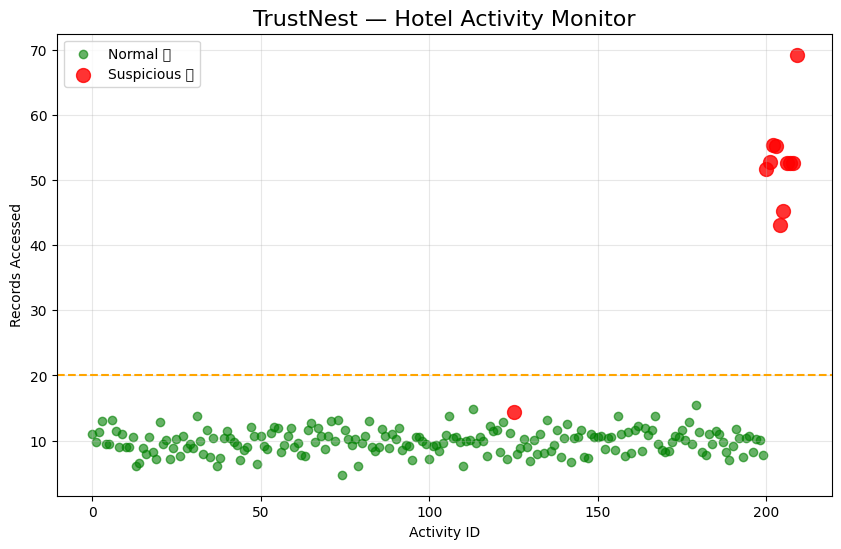

Dashboard generated!


In [ ]:
# Visualise the results
plt.figure(figsize=(10, 6))

# Plot normal activity
normal_data = df[df['status'] == 'NORMAL']
suspicious_data = df[df['status'] == 'SUSPICIOUS']

plt.scatter(normal_data.index, normal_data['records_accessed'],
            color='green', label='Normal ✅', alpha=0.6)
plt.scatter(suspicious_data.index, suspicious_data['records_accessed'],
            color='red', label='Suspicious 🚨', alpha=0.8, s=100)

plt.title('TrustNest — Hotel Activity Monitor', fontsize=16)
plt.xlabel('Activity ID')
plt.ylabel('Records Accessed')
plt.legend()
plt.axhline(y=20, color='orange', linestyle='--', label='Threshold')
plt.grid(True, alpha=0.3)
plt.show()

print("Dashboard generated!")

In [ ]:
# TrustNest — Real Time Alert System

import datetime

def check_activity(staff_name, records_accessed):
    """
    Checks if staff activity is suspicious
    and sends an alert if needed
    """

    # Run through our model
    activity = np.array([[records_accessed,
                         datetime.datetime.now().hour]])
    prediction = model.predict(activity)

    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    print("=" * 50)
    print("   TRUSTNEST REAL TIME MONITOR")
    print("=" * 50)
    print(f"Timestamp:        {timestamp}")
    print(f"Staff Member:     {staff_name}")
    print(f"Records Accessed: {records_accessed}")

    if prediction[0] == -1:
        print(f"Status:           🚨 SUSPICIOUS ACTIVITY!")
        print(f"ACTION:           Alert sent to manager!")
    else:
        print(f"Status:           ✅ Normal Activity")
    print("=" * 50)

# Test with different staff members
check_activity("Maria Schmidt", 8)   # Normal
check_activity("John Mueller", 52)   # Suspicious!
check_activity("Anna Weber", 11)     # Normal
check_activity("Unknown User", 67)   # Very suspicious!

   TRUSTNEST REAL TIME MONITOR
Timestamp:        2026-05-30 12:58:28
Staff Member:     Maria Schmidt
Records Accessed: 8
Status:           ✅ Normal Activity
   TRUSTNEST REAL TIME MONITOR
Timestamp:        2026-05-30 12:58:28
Staff Member:     John Mueller
Records Accessed: 52
Status:           🚨 SUSPICIOUS ACTIVITY!
ACTION:           Alert sent to manager!
   TRUSTNEST REAL TIME MONITOR
Timestamp:        2026-05-30 12:58:28
Staff Member:     Anna Weber
Records Accessed: 11
Status:           ✅ Normal Activity
   TRUSTNEST REAL TIME MONITOR
Timestamp:        2026-05-30 12:58:28
Staff Member:     Unknown User
Records Accessed: 67
Status:           🚨 SUSPICIOUS ACTIVITY!
ACTION:           Alert sent to manager!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


In [ ]:
# Fixed version - removes the warnings
def check_activity_v2(staff_name, records_accessed):

    import datetime

    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    # Fix - use proper dataframe format
    activity = pd.DataFrame({
        'records_accessed': [records_accessed],
        'hour_of_day': [datetime.datetime.now().hour]
    })

    prediction = model.predict(activity)

    print("=" * 50)
    print("   TRUSTNEST REAL TIME MONITOR")
    print("=" * 50)
    print(f"Timestamp:        {timestamp}")
    print(f"Staff Member:     {staff_name}")
    print(f"Records Accessed: {records_accessed}")

    if prediction[0] == -1:
        print(f"Status:           🚨 SUSPICIOUS ACTIVITY!")
        print(f"ACTION:           Alert sent to manager!")
    else:
        print(f"Status:           ✅ Normal Activity")
    print("=" * 50)

# Test again
check_activity_v2("Maria Schmidt", 8)
check_activity_v2("John Mueller", 52)

   TRUSTNEST REAL TIME MONITOR
Timestamp:        2026-05-30 12:58:28
Staff Member:     Maria Schmidt
Records Accessed: 8
Status:           ✅ Normal Activity
   TRUSTNEST REAL TIME MONITOR
Timestamp:        2026-05-30 12:58:28
Staff Member:     John Mueller
Records Accessed: 52
Status:           🚨 SUSPICIOUS ACTIVITY!
ACTION:           Alert sent to manager!


In [ ]:
# TrustNest — Email Alert Simulator
# (Simulates sending email to hotel manager)

def send_alert_email(staff_name, records_accessed, timestamp):

    email_content = f"""
    FROM: trustnest@security.com
    TO: manager@hotel.com
    SUBJECT: 🚨 SECURITY ALERT - Suspicious Activity Detected

    Dear Hotel Manager,

    TrustNest has detected suspicious activity in your system.

    Details:
    - Staff Member: {staff_name}
    - Records Accessed: {records_accessed}
    - Time: {timestamp}
    - Risk Level: HIGH

    Please investigate immediately.

    TrustNest Security System
    """

    print(email_content)
    print("✅ Alert email sent to manager!")

# Test it
import datetime
send_alert_email(
    "John Mueller",
    52,
    datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
)


    FROM: trustnest@security.com
    TO: manager@hotel.com
    SUBJECT: 🚨 SECURITY ALERT - Suspicious Activity Detected

    Dear Hotel Manager,

    TrustNest has detected suspicious activity in your system.

    Details:
    - Staff Member: John Mueller
    - Records Accessed: 52
    - Time: 2026-05-30 12:58:28
    - Risk Level: HIGH

    Please investigate immediately.

    TrustNest Security System
    
✅ Alert email sent to manager!


In [ ]:
# TRUSTNEST — Complete Security System v1.0

def trustnest_monitor(staff_name, records_accessed):

    import datetime
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    # Check activity
    activity = pd.DataFrame({
        'records_accessed': [records_accessed],
        'hour_of_day': [datetime.datetime.now().hour]
    })

    prediction = model.predict(activity)

    if prediction[0] == -1:
        print(f"🚨 ALERT: {staff_name} accessed {records_accessed} records at {timestamp}")
        send_alert_email(staff_name, records_accessed, timestamp)
    else:
        print(f"✅ NORMAL: {staff_name} accessed {records_accessed} records at {timestamp}")

# Simulate a full day of hotel activity
print("TRUSTNEST MONITORING SYSTEM — LIVE")
print("=" * 50)
trustnest_monitor("Anna Weber", 9)
trustnest_monitor("John Mueller", 55)
trustnest_monitor("Maria Schmidt", 12)
trustnest_monitor("Unknown User", 71)
trustnest_monitor("Peter Klein", 8)

TRUSTNEST MONITORING SYSTEM — LIVE
✅ NORMAL: Anna Weber accessed 9 records at 2026-05-30 12:58:28
🚨 ALERT: John Mueller accessed 55 records at 2026-05-30 12:58:28

    FROM: trustnest@security.com
    TO: manager@hotel.com
    SUBJECT: 🚨 SECURITY ALERT - Suspicious Activity Detected

    Dear Hotel Manager,

    TrustNest has detected suspicious activity in your system.

    Details:
    - Staff Member: John Mueller
    - Records Accessed: 55
    - Time: 2026-05-30 12:58:28
    - Risk Level: HIGH

    Please investigate immediately.

    TrustNest Security System
    
✅ Alert email sent to manager!
✅ NORMAL: Maria Schmidt accessed 12 records at 2026-05-30 12:58:28
🚨 ALERT: Unknown User accessed 71 records at 2026-05-30 12:58:28

    FROM: trustnest@security.com
    TO: manager@hotel.com
    SUBJECT: 🚨 SECURITY ALERT - Suspicious Activity Detected

    Dear Hotel Manager,

    TrustNest has detected suspicious activity in your system.

    Details:
    - Staff Member: Unknown User
    -

In [ ]:
# TrustNest — Login Security Monitor

import datetime

def monitor_login(staff_name, failed_attempts, login_hour):

    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    # Suspicious if more than 3 failed attempts
    # or logging in between 2am and 5am

    suspicious = False
    reason = []

    if failed_attempts > 3:
        suspicious = True
        reason.append(f"{failed_attempts} failed login attempts")

    if login_hour >= 2 and login_hour <= 5:
        suspicious = True
        reason.append(f"unusual login time ({login_hour}:00am)")

    print("=" * 50)
    print(f"Staff:    {staff_name}")
    print(f"Time:     {timestamp}")
    print(f"Failed attempts: {failed_attempts}")

    if suspicious:
        print(f"Status:   🚨 SUSPICIOUS!")
        for r in reason:
            print(f"Reason:   {r}")
        send_alert_email(staff_name, failed_attempts, timestamp)
    else:
        print(f"Status:   ✅ Normal")
    print("=" * 50)

# Test it
monitor_login("Anna Weber", 1, 9)      # Normal
monitor_login("Unknown User", 8, 3)    # Suspicious — too many attempts + odd hour
monitor_login("John Mueller", 5, 14)   # Suspicious — too many attempts
monitor_login("Maria Schmidt", 0, 8)   # Normal

Staff:    Anna Weber
Time:     2026-05-30 12:58:28
Failed attempts: 1
Status:   ✅ Normal
Staff:    Unknown User
Time:     2026-05-30 12:58:28
Failed attempts: 8
Status:   🚨 SUSPICIOUS!
Reason:   8 failed login attempts
Reason:   unusual login time (3:00am)

    FROM: trustnest@security.com
    TO: manager@hotel.com
    SUBJECT: 🚨 SECURITY ALERT - Suspicious Activity Detected

    Dear Hotel Manager,

    TrustNest has detected suspicious activity in your system.

    Details:
    - Staff Member: Unknown User
    - Records Accessed: 8
    - Time: 2026-05-30 12:58:28
    - Risk Level: HIGH

    Please investigate immediately.

    TrustNest Security System
    
✅ Alert email sent to manager!
Staff:    John Mueller
Time:     2026-05-30 12:58:28
Failed attempts: 5
Status:   🚨 SUSPICIOUS!
Reason:   5 failed login attempts

    FROM: trustnest@security.com
    TO: manager@hotel.com
    SUBJECT: 🚨 SECURITY ALERT - Suspicious Activity Detected

    Dear Hotel Manager,

    TrustNest has detect

In [ ]:
# TrustNest — Data Download Monitor

def monitor_download(staff_name, download_size_mb):

    import datetime
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    # Suspicious if download is over 100MB
    print("=" * 50)
    print(f"Staff:     {staff_name}")
    print(f"Download:  {download_size_mb} MB")
    print(f"Time:      {timestamp}")

    if download_size_mb > 100:
        print(f"Status:    🚨 SUSPICIOUS DOWNLOAD!")
        print(f"Reason:    Large data export detected")
        send_alert_email(staff_name, download_size_mb, timestamp)
    else:
        print(f"Status:    ✅ Normal Download")
    print("=" * 50)

# Test it
monitor_download("Anna Weber", 25)      # Normal
monitor_download("Unknown User", 450)   # Suspicious!
monitor_download("John Mueller", 80)    # Normal
monitor_download("Peter Klein", 200)    # Suspicious!

Staff:     Anna Weber
Download:  25 MB
Time:      2026-05-30 12:58:28
Status:    ✅ Normal Download
Staff:     Unknown User
Download:  450 MB
Time:      2026-05-30 12:58:28
Status:    🚨 SUSPICIOUS DOWNLOAD!
Reason:    Large data export detected

    FROM: trustnest@security.com
    TO: manager@hotel.com
    SUBJECT: 🚨 SECURITY ALERT - Suspicious Activity Detected

    Dear Hotel Manager,

    TrustNest has detected suspicious activity in your system.

    Details:
    - Staff Member: Unknown User
    - Records Accessed: 450
    - Time: 2026-05-30 12:58:28
    - Risk Level: HIGH

    Please investigate immediately.

    TrustNest Security System
    
✅ Alert email sent to manager!
Staff:     John Mueller
Download:  80 MB
Time:      2026-05-30 12:58:28
Status:    ✅ Normal Download
Staff:     Peter Klein
Download:  200 MB
Time:      2026-05-30 12:58:28
Status:    🚨 SUSPICIOUS DOWNLOAD!
Reason:    Large data export detected

    FROM: trustnest@security.com
    TO: manager@hotel.com
    SUB

In [ ]:
# TRUSTNEST v1.0 — Complete Security System

def trustnest_full_scan(staff_name, records_accessed,
                         failed_logins, login_hour,
                         download_mb):

    print("\n" + "=" * 50)
    print("   🔐 TRUSTNEST COMPLETE SECURITY SCAN")
    print("=" * 50)
    print(f"Staff: {staff_name}")
    print("-" * 50)

    # Run all 3 checks
    monitor_login(staff_name, failed_logins, login_hour)
    trustnest_monitor(staff_name, records_accessed)
    monitor_download(staff_name, download_mb)

    print("=" * 50)
    print("   SCAN COMPLETE")
    print("=" * 50)

# Test full system
trustnest_full_scan("Anna Weber", 9, 1, 9, 25)
trustnest_full_scan("Unknown Hacker", 71, 8, 3, 450)


   🔐 TRUSTNEST COMPLETE SECURITY SCAN
Staff: Anna Weber
--------------------------------------------------
Staff:    Anna Weber
Time:     2026-05-30 12:58:28
Failed attempts: 1
Status:   ✅ Normal
✅ NORMAL: Anna Weber accessed 9 records at 2026-05-30 12:58:28
Staff:     Anna Weber
Download:  25 MB
Time:      2026-05-30 12:58:28
Status:    ✅ Normal Download
   SCAN COMPLETE

   🔐 TRUSTNEST COMPLETE SECURITY SCAN
Staff: Unknown Hacker
--------------------------------------------------
Staff:    Unknown Hacker
Time:     2026-05-30 12:58:28
Failed attempts: 8
Status:   🚨 SUSPICIOUS!
Reason:   8 failed login attempts
Reason:   unusual login time (3:00am)

    FROM: trustnest@security.com
    TO: manager@hotel.com
    SUBJECT: 🚨 SECURITY ALERT - Suspicious Activity Detected

    Dear Hotel Manager,

    TrustNest has detected suspicious activity in your system.

    Details:
    - Staff Member: Unknown Hacker
    - Records Accessed: 8
    - Time: 2026-05-30 12:58:28
    - Risk Level: HIGH

 

In [ ]:
# Install Flask for web interface
!pip install flask pyngrok

In [ ]:
from flask import Flask, render_template_string
import datetime

app = Flask(__name__)

# HTML template for TrustNest dashboard
HTML_TEMPLATE = """
<!DOCTYPE html>
<html>
<head>
    <title>TrustNest Security Dashboard</title>
    <style>
        body { font-family: Arial; background: #1a1a2e; color: white; padding: 20px; }
        h1 { color: #00d4ff; text-align: center; }
        .alert { background: #ff4444; padding: 15px; margin: 10px; border-radius: 8px; }
        .normal { background: #00aa44; padding: 15px; margin: 10px; border-radius: 8px; }
        .header { text-align: center; padding: 20px; border-bottom: 2px solid #00d4ff; }
    </style>
</head>
<body>
    <div class="header">
        <h1>🔐 TrustNest Security Dashboard</h1>
        <p>AI-Powered Hotel Cybersecurity Platform</p>
    </div>

    <h2>Recent Activity:</h2>
    {% for activity in activities %}
        {% if activity.suspicious %}
            <div class="alert">
                🚨 SUSPICIOUS: {{ activity.name }} —
                {{ activity.records }} records at {{ activity.time }}
            </div>
        {% else %}
            <div class="normal">
                ✅ NORMAL: {{ activity.name }} —
                {{ activity.records }} records at {{ activity.time }}
            </div>
        {% endif %}
    {% endfor %}
</body>
</html>
"""

@app.route('/')
def dashboard():
    activities = [
        {"name": "Anna Weber", "records": 9, "suspicious": False,
         "time": datetime.datetime.now().strftime("%H:%M:%S")},
        {"name": "Unknown Hacker", "records": 71, "suspicious": True,
         "time": datetime.datetime.now().strftime("%H:%M:%S")},
        {"name": "Maria Schmidt", "records": 12, "suspicious": False,
         "time": datetime.datetime.now().strftime("%H:%M:%S")},
        {"name": "John Mueller", "records": 55, "suspicious": True,
         "time": datetime.datetime.now().strftime("%H:%M:%S")},
    ]
    return render_template_string(HTML_TEMPLATE, activities=activities)

print("TrustNest Dashboard ready!")

TrustNest Dashboard ready!


In [ ]:
from pyngrok import ngrok
ngrok.set_auth_token("3EQ2bz70990L2Fh5t7iAcsAllpO_3mpEGiRiLSH7hbGM57ErP")
print("Token set successfully!")

Token set successfully!


In [ ]:
import threading

def run_app():
    app.run(port=5000, use_reloader=False)

thread = threading.Thread(target=run_app)
thread.daemon = True
thread.start()

public_url = ngrok.connect(5000)
print(f"TrustNest is LIVE!")
print(f"Open this link: {public_url}")


 * Serving Flask app '__main__'
 * Debug mode: off


Address already in use
Port 5000 is in use by another program. Either identify and stop that program, or start the server with a different port.


TrustNest is LIVE!
Open this link: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5000"


In [ ]:
# Install database library
!pip install sqlalchemy

In [ ]:
from sqlalchemy import create_engine, Column, Integer, String, DateTime, Boolean
from sqlalchemy.ext.declarative import declarative_base
from sqlalchemy.orm import sessionmaker
import datetime

# Create database
engine = create_engine('sqlite:///trustnest.db')
Base = declarative_base()

# Create security alerts table
class SecurityAlert(Base):
    __tablename__ = 'security_alerts'

    id = Column(Integer, primary_key=True)
    staff_name = Column(String)
    activity_type = Column(String)
    value = Column(Integer)
    suspicious = Column(Boolean)
    timestamp = Column(DateTime, default=datetime.datetime.now)

# Create the table
Base.metadata.create_all(engine)
Session = sessionmaker(bind=engine)
session = Session()

print("✅ TrustNest Database created successfully!")

✅ TrustNest Database created successfully!


/tmp/ipykernel_611/1258819252.py:8: MovedIn20Warning: The ``declarative_base()`` function is now available as sqlalchemy.orm.declarative_base(). (deprecated since: 2.0) (Background on SQLAlchemy 2.0 at: https://sqlalche.me/e/b8d9)
  Base = declarative_base()


In [ ]:
# Save security alerts to database

def save_alert(staff_name, activity_type, value, suspicious):
    alert = SecurityAlert(
        staff_name=staff_name,
        activity_type=activity_type,
        value=value,
        suspicious=suspicious,
        timestamp=datetime.datetime.now()
    )
    session.add(alert)
    session.commit()
    print(f"✅ Saved to database: {staff_name} — {activity_type}")

# Test saving alerts
save_alert("Anna Weber", "records_accessed", 9, False)
save_alert("Unknown Hacker", "records_accessed", 71, True)
save_alert("John Mueller", "login_attempts", 5, True)
save_alert("Maria Schmidt", "download_mb", 25, False)

print("\n✅ All alerts saved to TrustNest database!")

✅ Saved to database: Anna Weber — records_accessed
✅ Saved to database: Unknown Hacker — records_accessed
✅ Saved to database: John Mueller — login_attempts
✅ Saved to database: Maria Schmidt — download_mb

✅ All alerts saved to TrustNest database!


In [ ]:
# Read all alerts from database

def show_all_alerts():
    alerts = session.query(SecurityAlert).all()

    print("=" * 50)
    print("   📊 TRUSTNEST DATABASE REPORT")
    print("=" * 50)

    for alert in alerts:
        if alert.suspicious:
            print(f"🚨 SUSPICIOUS | {alert.staff_name} | "
                  f"{alert.activity_type} | "
                  f"Value: {alert.value} | "
                  f"Time: {alert.timestamp.strftime('%H:%M:%S')}")
        else:
            print(f"✅ NORMAL    | {alert.staff_name} | "
                  f"{alert.activity_type} | "
                  f"Value: {alert.value} | "
                  f"Time: {alert.timestamp.strftime('%H:%M:%S')}")

    print("=" * 50)
    total = len(alerts)
    suspicious = len([a for a in alerts if a.suspicious])
    print(f"Total Alerts: {total} | Suspicious: {suspicious}")
    print("=" * 50)

show_all_alerts()

   📊 TRUSTNEST DATABASE REPORT
✅ NORMAL    | Anna Weber | records_accessed | Value: 9 | Time: 12:57:11
🚨 SUSPICIOUS | Unknown Hacker | records_accessed | Value: 71 | Time: 12:57:11
🚨 SUSPICIOUS | John Mueller | login_attempts | Value: 5 | Time: 12:57:11
✅ NORMAL    | Maria Schmidt | download_mb | Value: 25 | Time: 12:57:11
✅ NORMAL    | Anna Weber | records_accessed | Value: 9 | Time: 12:58:56
🚨 SUSPICIOUS | Unknown Hacker | records_accessed | Value: 71 | Time: 12:58:57
🚨 SUSPICIOUS | John Mueller | login_attempts | Value: 5 | Time: 12:58:57
✅ NORMAL    | Maria Schmidt | download_mb | Value: 25 | Time: 12:58:57
Total Alerts: 8 | Suspicious: 4


In [ ]:
from sqlalchemy import create_engine, Column, Integer, String, DateTime, Boolean
from sqlalchemy.orm import declarative_base, sessionmaker
import datetime

engine = create_engine('sqlite:///trustnest.db')
Base = declarative_base()

class SecurityAlert(Base):
    __tablename__ = 'security_alerts'
    __table_args__ = {'extend_existing': True}

    id = Column(Integer, primary_key=True)
    staff_name = Column(String)
    activity_type = Column(String)
    value = Column(Integer)
    suspicious = Column(Boolean)
    timestamp = Column(DateTime, default=datetime.datetime.now)

class HotelUser(Base):
    __tablename__ = 'hotel_users'
    __table_args__ = {'extend_existing': True}

    id = Column(Integer, primary_key=True)
    hotel_name = Column(String)
    username = Column(String)
    password_hash = Column(String)
    created_at = Column(DateTime, default=datetime.datetime.now)

Base.metadata.create_all(engine)
Session = sessionmaker(bind=engine)
session = Session()

print("✅ Database ready!")

✅ Database ready!


In [ ]:
# TRUSTNEST COMPLETE SYSTEM v2.0

def trustnest_complete(username, password, staff_name,
                        records_accessed, failed_logins,
                        login_hour, download_mb):

    print("=" * 50)
    print("   🔐 TRUSTNEST v2.0 — FULL SYSTEM")
    print("=" * 50)

    # Step 1 — Verify hotel login
    if not login(username, password):
        print("❌ Access denied!")
        return

    # Step 2 — Run security scan
    trustnest_full_scan(staff_name, records_accessed,
                        failed_logins, login_hour, download_mb)

    # Step 3 — Save to database
    suspicious = records_accessed > 20 or failed_logins > 3
    save_alert(staff_name, "full_scan", records_accessed, suspicious)

    print("✅ Report saved to database!")
    print("=" * 50)

# Test complete system
trustnest_complete(
    "munich_manager", "secure123",
    "Unknown Hacker", 71, 8, 3, 450
)

   🔐 TRUSTNEST v2.0 — FULL SYSTEM


NameError: name 'login' is not defined

In [ ]:
import hashlib

def hash_password(password):
    return hashlib.sha256(password.encode()).hexdigest()

def login(username, password):
    user = session.query(HotelUser).filter_by(
        username=username,
        password_hash=hash_password(password)
    ).first()

    if user:
        print(f"✅ Login successful! Welcome {user.hotel_name}!")
        return True
    else:
        print(f"🚨 Login failed! Invalid credentials!")
        return False

print("✅ Login function ready!")

✅ Login function ready!


In [ ]:
# 🔐 TrustNest
## AI-Powered Cybersecurity Platform for Hotels

### What is TrustNest?
TrustNest is a B2B SaaS platform that protects independent hotels
from cybersecurity threats using artificial intelligence.

### The Problem
- 53% of hotel managers surveyed experienced data breaches
- Independent hotels can't afford expensive security systems
- Guest data is at risk every day

### Our Solution
TrustNest monitors hotel systems 24/7 using AI to:
- Detect suspicious staff activity
- Monitor login failures
- Track unusual data downloads
- Send instant alerts to managers

### Technology Stack
- Python & Scikit-learn (AI Model)
- Flask (Web Interface)
- SQLite (Database)
- Hugging Face (NLP)
- Microsoft Fabric (Data Pipeline)

### Market
- German hospitality market: €78.5 billion
- Target: 50,000+ independent hotels in Germany

### Business Model
- Basic: €500/month per hotel
- Standard: €1,000/month per hotel
- Premium: €2,000/month per hotel

### Founded by
Suneeta Ramanathan
MSc Business Analytics & Data Science
EU Business School Munich

SyntaxError: unterminated string literal (detected at line 10) (1891709951.py, line 10)

In [ ]:
# TrustNest Website — Homepage

website_html = """
<!DOCTYPE html>
<html>
<head>
    <title>TrustNest — Hotel Cybersecurity</title>
    <style>
        body {
            font-family: Arial;
            background: #1a1a2e;
            color: white;
            margin: 0;
            padding: 0;
        }
        .hero {
            text-align: center;
            padding: 80px 20px;
            background: linear-gradient(135deg, #1a1a2e, #16213e);
        }
        h1 { color: #00d4ff; font-size: 48px; }
        .subtitle { font-size: 20px; color: #aaa; }
        .button {
            background: #00d4ff;
            color: black;
            padding: 15px 40px;
            border: none;
            border-radius: 25px;
            font-size: 18px;
            cursor: pointer;
            margin-top: 30px;
            display: inline-block;
        }
        .features {
            display: flex;
            justify-content: center;
            gap: 30px;
            padding: 60px 20px;
            flex-wrap: wrap;
        }
        .feature {
            background: #16213e;
            padding: 30px;
            border-radius: 15px;
            width: 250px;
            text-align: center;
        }
        .feature h3 { color: #00d4ff; }
        .pricing {
            text-align: center;
            padding: 60px 20px;
            background: #16213e;
        }
        .price-card {
            display: inline-block;
            background: #1a1a2e;
            padding: 30px;
            border-radius: 15px;
            margin: 10px;
            width: 200px;
        }
        .price { color: #00d4ff; font-size: 32px; font-weight: bold; }
        .footer {
            text-align: center;
            padding: 30px;
            color: #aaa;
            font-size: 14px;
        }
    </style>
</head>
<body>
    <div class="hero">
        <h1>🔐 TrustNest</h1>
        <p class="subtitle">AI-Powered Cybersecurity for Independent Hotels</p>
        <p>Protect your guests. Secure your data. Sleep peacefully.</p>
        <a href="/signup" style="text-decoration:none"><div class="button">Get Started Free</div></a>
    </div>

    <div class="features">
        <div class="feature">
            <h3>🤖 AI Detection</h3>
            <p>Our AI monitors your hotel systems 24/7 and detects suspicious activity instantly</p>
        </div>
        <div class="feature">
            <h3>🚨 Instant Alerts</h3>
            <p>Get notified immediately when a security threat is detected in your system</p>
        </div>
        <div class="feature">
            <h3>📊 Dashboard</h3>
            <p>See all your security activity in one clean, easy to understand dashboard</p>
        </div>
        <div class="feature">
            <h3>🔒 GDPR Safe</h3>
            <p>Fully compliant with German data protection laws — your guests data is safe</p>
        </div>
    </div>

    <div class="pricing">
        <h2>Simple Pricing</h2>
        <div class="price-card">
            <h3>Basic</h3>
            <div class="price">€500</div>
            <p>/month</p>
            <p>Security monitoring + alerts</p>
        </div>
        <div class="price-card">
            <h3>Standard</h3>
            <div class="price">€1,000</div>
            <p>/month</p>
            <p>Everything + AI analytics</p>
        </div>
        <div class="price-card">
            <h3>Premium</h3>
            <div class="price">€2,000</div>
            <p>/month</p>
            <p>Full platform + support</p>
        </div>
    </div>

    <div class="footer">
        <p>© 2026 TrustNest — Founded by Suneeta Ramanathan</p>
        <p>Munich, Germany | inboxsuneeta26@gmail.com</p>
    </div>
</body>
</html>
"""

# Save the website
with open('trustnest_website.html', 'w') as f:
    f.write(website_html)

print("✅ TrustNest website created!")

✅ TrustNest website created!


In [ ]:
from flask import Flask, request, redirect

app4 = Flask(__name__)

with open('trustnest_website.html', 'r') as f:
    website_content = f.read()

with open('trustnest_signup.html', 'r') as f:
    signup_content = f.read()

with open('trustnest_login.html', 'r') as f:
    login_content = f.read()

@app4.route('/home')
def home():
    return website_content

@app4.route('/signup')
def signup():
    return signup_content

@app4.route('/login')
def login_page():
    return login_content

print("✅ All pages connected!")

FileNotFoundError: [Errno 2] No such file or directory: 'trustnest_signup.html'

In [ ]:
from flask import Flask, render_template_string
app2 = Flask(__name__)

with open('trustnest_website.html', 'r') as f:
    website_content = f.read()

@app2.route('/home')
def home():
    return website_content

print("✅ Website ready to launch!")

✅ Website ready to launch!


In [ ]:
public_url6 = ngrok.connect(5005)
print(f"🔐 TrustNest LIVE!")
print(f"Home: {public_url6}/home")
print(f"Signup: {public_url6}/signup")
print(f"Login: {public_url6}/login")

🔐 TrustNest LIVE!
Home: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5005"/home
Signup: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5005"/signup
Login: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5005"/login


In [ ]:
import threading

def run_website():
    app2.run(port=5001, use_reloader=False)

thread2 = threading.Thread(target=run_website)
thread2.daemon = True
thread2.start()

public_url2 = ngrok.connect(5001)
print("=" * 50)
print("🔐 TRUSTNEST WEBSITE IS LIVE!")
print("=" * 50)
print(f"Share this link: {public_url2}")
print("=" * 50)

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5001
INFO:werkzeug:Press CTRL+C to quit


🔐 TRUSTNEST WEBSITE IS LIVE!
Share this link: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5001"


In [ ]:
signup_html = """
<!DOCTYPE html>
<html>
<head>
    <title>TrustNest — Sign Up</title>
    <style>
        body {
            font-family: Arial;
            background: #1a1a2e;
            color: white;
            margin: 0;
            padding: 0;
        }
        .container {
            max-width: 500px;
            margin: 80px auto;
            background: #16213e;
            padding: 40px;
            border-radius: 15px;
        }
        h1 { color: #00d4ff; text-align: center; }
        input {
            width: 100%;
            padding: 12px;
            margin: 10px 0;
            border-radius: 8px;
            border: 1px solid #00d4ff;
            background: #1a1a2e;
            color: white;
            font-size: 16px;
            box-sizing: border-box;
        }
        .button {
            width: 100%;
            background: #00d4ff;
            color: black;
            padding: 15px;
            border: none;
            border-radius: 25px;
            font-size: 18px;
            cursor: pointer;
            margin-top: 20px;
        }
        .login-link {
            text-align: center;
            margin-top: 20px;
            color: #aaa;
        }
        a { color: #00d4ff; }
    </style>
</head>
<body>
    <div class="container">
        <h1>🔐 TrustNest</h1>
        <h2 style="text-align:center">Create Your Account</h2>

        <form action="/authenticate" method="POST">
<form action="/authenticate" method="POST">
<input type="text" name="hotel" placeholder="Hotel Name" />
<input type="text" name="name" placeholder="Your Full Name" />
<input type="email" name="username" placeholder="Email Address" />
<input type="tel" name="phone" placeholder="Phone Number" />
<input type="password" name="password" placeholder="Create Password" />
<button type="submit" class="button">Start Free Trial</button>
</form>

        <div class="login-link">
            Already have an account? <a href="#">Login here</a>
        </div>
    </div>
</body>
</html>
"""

with open('trustnest_signup.html', 'w') as f:
    f.write(signup_html)

print("✅ Signup page created!")
with open('trustnest_signup.html', 'w') as f:
    f.write(signup_html)
print("✅ Signup saved!")

✅ Signup page created!
✅ Signup saved!


In [ ]:
import threading

def run_app5():
    app5.run(port=5006, use_reloader=False)

thread7 = threading.Thread(target=run_app5)
thread7.daemon = True
thread7.start()

public_url7 = ngrok.connect(5006)
print(f"🔐 TrustNest LIVE!")
print(f"Home: {public_url7}/home")
print(f"Signup: {public_url7}/signup")
print(f"Login: {public_url7}/login")

Exception in thread Thread-7 (run_app5):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/tmp/ipykernel_611/2108577941.py", line 4, in run_app5
NameError: name 'app5' is not defined. Did you mean: 'app'?


🔐 TrustNest LIVE!
Home: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5006"/home
Signup: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5006"/signup
Login: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5006"/login


In [ ]:
from flask import Flask, request, redirect

app6 = Flask(__name__)

with open('trustnest_website.html', 'r') as f:
    website_content = f.read()

with open('trustnest_signup.html', 'r') as f:
    signup_content = f.read()

with open('trustnest_login.html', 'r') as f:
    login_content = f.read()

@app6.route('/home')
def home():
    return website_content

@app6.route('/signup')
def signup():
    return signup_content

@app6.route('/login')
def login_page():
    return login_content

@app6.route('/authenticate', methods=['POST'])
def authenticate():
    return redirect('/dashboard')

@app6.route('/dashboard')
def dashboard():
    return open('trustnest_website.html').read()

print("All pages ready!")

FileNotFoundError: [Errno 2] No such file or directory: 'trustnest_login.html'

In [ ]:
# Recreate all HTML files

login_html = """<!DOCTYPE html>
<html>
<head>
    <title>TrustNest Login</title>
    <style>
        body{font-family:Arial;background:#1a1a2e;color:white;margin:0;padding:0;}
        .container{max-width:500px;margin:80px auto;background:#16213e;padding:40px;border-radius:15px;}
        h1{color:#00d4ff;text-align:center;}
        input{width:100%;padding:12px;margin:10px 0;border-radius:8px;border:1px solid #00d4ff;background:#1a1a2e;color:white;font-size:16px;box-sizing:border-box;}
        .button{width:100%;background:#00d4ff;color:black;padding:15px;border:none;border-radius:25px;font-size:18px;cursor:pointer;margin-top:20px;}
        a{color:#00d4ff;}
    </style>
</head>
<body>
<div class="container">
    <h1>🔐 TrustNest</h1>
    <h2 style="text-align:center">Welcome Back</h2>
    <form action="/authenticate" method="POST">
    <input type="email" name="username" placeholder="Email Address"/>
    <input type="password" name="password" placeholder="Password"/>
    <button type="submit" class="button">Login to Dashboard</button>
    </form>
    <p style="text-align:center">Don't have an account? <a href="/signup">Sign up here</a></p>
</div>
</body>
</html>"""

with open('trustnest_login.html', 'w') as f:
    f.write(login_html)

signup_html = """<!DOCTYPE html>
<html>
<head>
    <title>TrustNest Signup</title>
    <style>
        body{font-family:Arial;background:#1a1a2e;color:white;margin:0;padding:0;}
        .container{max-width:500px;margin:80px auto;background:#16213e;padding:40px;border-radius:15px;}
        h1{color:#00d4ff;text-align:center;}
        input{width:100%;padding:12px;margin:10px 0;border-radius:8px;border:1px solid #00d4ff;background:#1a1a2e;color:white;font-size:16px;box-sizing:border-box;}
        .button{width:100%;background:#00d4ff;color:black;padding:15px;border:none;border-radius:25px;font-size:18px;cursor:pointer;margin-top:20px;}
        a{color:#00d4ff;}
    </style>
</head>
<body>
<div class="container">
    <h1>🔐 TrustNest</h1>
    <h2 style="text-align:center">Create Your Account</h2>
    <form action="/authenticate" method="POST">
    <input type="text" name="hotel" placeholder="Hotel Name"/>
    <input type="text" name="name" placeholder="Your Full Name"/>
    <input type="email" name="username" placeholder="Email Address"/>
    <input type="password" name="password" placeholder="Password"/>
    <button type="submit" class="button">Start Free Trial</button>
    </form>
    <p style="text-align:center">Already have an account? <a href="/login">Login here</a></p>
</div>
</body>
</html>"""

with open('trustnest_signup.html', 'w') as f:
    f.write(signup_html)

contact_html = """<!DOCTYPE html>
<html>
<head>
    <title>TrustNest Contact</title>
    <style>
        body{font-family:Arial;background:#1a1a2e;color:white;margin:0;padding:0;}
        .container{max-width:500px;margin:80px auto;background:#16213e;padding:40px;border-radius:15px;}
        h1{color:#00d4ff;text-align:center;}
        input,textarea{width:100%;padding:12px;margin:10px 0;border-radius:8px;border:1px solid #00d4ff;background:#1a1a2e;color:white;font-size:16px;box-sizing:border-box;}
        textarea{height:120px;}
        .button{width:100%;background:#00d4ff;color:black;padding:15px;border:none;border-radius:25px;font-size:18px;cursor:pointer;margin-top:20px;}
    </style>
</head>
<body>
<div class="container">
    <h1>Contact TrustNest</h1>
    <form action="/contact_submit" method="POST">
    <input type="text" name="hotel_name" placeholder="Hotel Name"/>
    <input type="text" name="name" placeholder="Your Name"/>
    <input type="email" name="email" placeholder="Email Address"/>
    <textarea name="message" placeholder="Tell us about your hotel..."></textarea>
    <button type="submit" class="button">Send Message</button>
    </form>
</div>
</body>
</html>"""

with open('trustnest_contact.html', 'w') as f:
    f.write(contact_html)

print("✅ All HTML files recreated!")

✅ All HTML files recreated!


In [ ]:
import threading

def run_app6():
    app6.run(port=5009, use_reloader=False)

thread8 = threading.Thread(target=run_app6)
thread8.daemon = True
thread8.start()

public_url8 = ngrok.connect(5009)
print(f"Home: {public_url8}/home")
print(f"Signup: {public_url8}/signup")
print(f"Login: {public_url8}/login")

 * Serving Flask app '__main__'
 * Debug mode: off


Address already in use
Port 5009 is in use by another program. Either identify and stop that program, or start the server with a different port.


PyngrokNgrokHTTPError: ngrok client exception, API returned 502: {"error_code":103,"status_code":502,"msg":"failed to start tunnel","details":{"err":"failed to start tunnel: Your account may not run more than 5 endpoints over a single ngrok agent session.\nThe endpoints already running on this session are:\ntn_3ERfDpdCiI4M25iqGsxPczAGnaA, tn_3ERfEDYHW526pEsGIW4RmWNHYm9, tn_3ERfF2IU7WET41CJLPlD5IZ6zry, tn_3EReT2hlQrH0o245wRIqoxM5aBH, tn_3EReh5mhXj3VdazaFE1p4oUa1p3.\nUpgrade to a Pay-as-you-go plan at: https://dashboard.ngrok.com/billing/choose-a-plan?plan=paygo\r\n\r\nERR_NGROK_324\r\n"}}


In [ ]:
from pyngrok import ngrok
ngrok.kill()
print("All tunnels killed!")

All tunnels killed!


In [ ]:
from flask import Flask, request, redirect
import threading

app_new = Flask(__name__)

with open('trustnest_login.html', 'r') as f:
    login_content = f.read()
with open('trustnest_signup.html', 'r') as f:
    signup_content = f.read()
with open('trustnest_contact.html', 'r') as f:
    contact_content = f.read()

nav_bar = """<nav style="background:#16213e;padding:15px;display:flex;justify-content:space-between;align-items:center;">
<a href="/home" style="color:#00d4ff;text-decoration:none;font-size:20px;font-weight:bold;">🔐 TrustNest</a>
<div>
<a href="/home" style="color:white;text-decoration:none;margin:0 15px;">Home</a>
<a href="/contact" style="color:white;text-decoration:none;margin:0 15px;">Contact</a>
<a href="/login" style="color:white;text-decoration:none;margin:0 15px;">Login</a>
<a href="/signup" style="color:#00d4ff;text-decoration:none;margin:0 15px;border:1px solid #00d4ff;padding:8px 15px;border-radius:20px;">Get Started</a>
</div>
</nav>"""

@app_new.route('/')
@app_new.route('/home')
def home():
    return """<!DOCTYPE html>
<html>
<head><title>TrustNest</title>
<style>
body{font-family:Arial;background:#1a1a2e;color:white;margin:0;padding:0;}
.hero{text-align:center;padding:80px 20px;}
h1{color:#00d4ff;font-size:48px;}
.button{background:#00d4ff;color:black;padding:15px 40px;border:none;border-radius:25px;font-size:18px;cursor:pointer;margin-top:30px;display:inline-block;text-decoration:none;}
.features{display:flex;justify-content:center;gap:30px;padding:60px 20px;flex-wrap:wrap;}
.feature{background:#16213e;padding:30px;border-radius:15px;width:250px;text-align:center;}
.feature h3{color:#00d4ff;}
.pricing{text-align:center;padding:60px 20px;background:#16213e;}
.price-card{display:inline-block;background:#1a1a2e;padding:30px;border-radius:15px;margin:10px;width:200px;}
.price{color:#00d4ff;font-size:32px;font-weight:bold;}
</style>
</head>
<body>""" + nav_bar + """
<div class="hero">
<h1>🔐 TrustNest</h1>
<p>AI-Powered Cybersecurity for Independent Hotels</p>
<p>Protect your guests. Secure your data. Sleep peacefully.</p>
<a href="/signup" class="button">Get Started Free</a>
</div>
<div class="features">
<div class="feature"><h3>🤖 AI Detection</h3><p>Monitors hotel systems 24/7</p></div>
<div class="feature"><h3>🚨 Instant Alerts</h3><p>Get notified immediately</p></div>
<div class="feature"><h3>📊 Dashboard</h3><p>See all activity clearly</p></div>
<div class="feature"><h3>🔒 GDPR Safe</h3><p>Fully compliant</p></div>
</div>
<div class="pricing">
<h2>Simple Pricing</h2>
<div class="price-card"><h3>Basic</h3><div class="price">500</div><p>euros/month</p></div>
<div class="price-card"><h3>Standard</h3><div class="price">1,000</div><p>euros/month</p></div>
<div class="price-card"><h3>Premium</h3><div class="price">2,000</div><p>euros/month</p></div>
</div>
<p style="text-align:center;padding:20px;color:#aaa">2026 TrustNest - Founded by Suneeta Ramanathan</p>
</body>
</html>"""

@app_new.route('/login')
def login_page():
    return login_content

@app_new.route('/signup')
def signup():
    return signup_content

@app_new.route('/contact')
def contact():
    return contact_content

@app_new.route('/authenticate', methods=['GET', 'POST'])
def authenticate():
    return redirect('/dashboard')

@app_new.route('/contact_submit', methods=['POST'])
def c

SyntaxError: expected '(' (3295056065.py, line 82)

In [ ]:
from pyngrok import ngrok
ngrok.kill()
print("Tunnels cleared!")

Tunnels cleared!


In [ ]:
from flask import Flask, request, redirect
import threading

app_new = Flask(__name__)

with open('trustnest_login.html', 'r') as f:
    login_content = f.read()
with open('trustnest_signup.html', 'r') as f:
    signup_content = f.read()
with open('trustnest_contact.html', 'r') as f:
    contact_content = f.read()

@app_new.route('/')
@app_new.route('/home')
def home():
    return "<h1 style='color:#00d4ff;background:#1a1a2e;padding:40px;text-align:center'>🔐 TrustNest Home</h1><a href='/signup' style='color:#00d4ff;display:block;text-align:center'>Get Started</a>"

@app_new.route('/login')
def login_page():
    return login_content

@app_new.route('/signup')
def signup():
    return signup_content

@app_new.route('/contact')
def contact():
    return contact_content

@app_new.route('/authenticate', methods=['GET', 'POST'])
def authenticate():
    return redirect('/dashboard')

@app_new.route('/dashboard')
def dashboard():
    return "<h1 style='color:#00d4ff;background:#1a1a2e;padding:40px;text-align:center'>🔐 TrustNest Dashboard</h1>"

def run_new():
    app_new.run(port=6001, use_reloader=False)

thread_new = threading.Thread(target=run_new)
thread_new.daemon = True
thread_new.start()

url_new = ngrok.connect(6001)
print(f"Home: {url_new}/home")
print(f"Login: {url_new}/login")
print(f"Dashboard: {url_new}/dashboard")

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:6001
INFO:werkzeug:Press CTRL+C to quit


Home: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:6001"/home
Login: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:6001"/login
Dashboard: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:6001"/dashboard


In [ ]:
from pyngrok import ngrok
ngrok.kill()

from flask import Flask, request, redirect
import threading

app_full = Flask(__name__)

with open('trustnest_login.html', 'r') as f:
    login_content = f.read()
with open('trustnest_signup.html', 'r') as f:
    signup_content = f.read()
with open('trustnest_contact.html', 'r') as f:
    contact_content = f.read()

nav = """<nav style="background:#16213e;padding:15px;display:flex;justify-content:space-between;align-items:center;">
<a href="/home" style="color:#00d4ff;text-decoration:none;font-size:20px;font-weight:bold;">🔐 TrustNest</a>
<div>
<a href="/home" style="color:white;text-decoration:none;margin:0 15px;">Home</a>
<a href="/contact" style="color:white;text-decoration:none;margin:0 15px;">Contact</a>
<a href="/login" style="color:white;text-decoration:none;margin:0 15px;">Login</a>
<a href="/signup" style="color:#00d4ff;text-decoration:none;margin:0 15px;border:1px solid #00d4ff;padding:8px 15px;border-radius:20px;">Get Started</a>
</div>
</nav>"""

@app_full.route('/')
@app_full.route('/home')
def home():
    return nav + """
    <div style="text-align:center;padding:80px 20px;background:#1a1a2e;color:white;">
    <h1 style="color:#00d4ff;font-size:48px;">🔐 TrustNest</h1>
    <p style="font-size:20px;">AI-Powered Cybersecurity for Independent Hotels</p>
    <p>Protect your guests. Secure your data. Sleep peacefully.</p>
    <a href="/signup" style="background:#00d4ff;color:black;padding:15px 40px;border-radius:25px;font-size:18px;text-decoration:none;display:inline-block;margin-top:20px;">Get Started Free</a>
    </div>
    <div style="display:flex;justify-content:center;gap:30px;padding:60px 20px;background:#1a1a2e;flex-wrap:wrap;">
    <div style="background:#16213e;padding:30px;border-radius:15px;width:220px;text-align:center;color:white;">
    <h3 style="color:#00d4ff;">🤖 AI Detection</h3><p>Monitors hotel systems 24/7</p></div>
    <div style="background:#16213e;padding:30px;border-radius:15px;width:220px;text-align:center;color:white;">
    <h3 style="color:#00d4ff;">🚨 Instant Alerts</h3><p>Get notified immediately</p></div>
    <div style="background:#16213e;padding:30px;border-radius:15px;width:220px;text-align:center;color:white;">
    <h3 style="color:#00d4ff;">📊 Dashboard</h3><p>See all activity clearly</p></div>
    <div style="background:#16213e;padding:30px;border-radius:15px;width:220px;text-align:center;color:white;">
    <h3 style="color:#00d4ff;">🔒 GDPR Safe</h3><p>Fully compliant</p></div>
    </div>
    <div style="text-align:center;padding:60px 20px;background:#16213e;color:white;">
    <h2>Simple Pricing</h2>
    <div style="display:inline-block;background:#1a1a2e;padding:30px;border-radius:15px;margin:10px;width:180px;">
    <h3>Basic</h3><h2 style="color:#00d4ff;">€500</h2><p>/month</p></div>
    <div style="display:inline-block;background:#1a1a2e;padding:30px;border-radius:15px;margin:10px;width:180px;">
    <h3>Standard</h3><h2 style="color:#00d4ff;">€1,000</h2><p>/month</p></div>
    <div style="display:inline-block;background:#1a1a2e;padding:30px;border-radius:15px;margin:10px;width:180px;">
    <h3>Premium</h3><h2 style="color:#00d4ff;">€2,000</h2><p>/month</p></div>
    </div>
    <p style="text-align:center;padding:20px;color:#aaa;background:#1a1a2e;">© 2026 TrustNest — Founded by Suneeta Ramanathan · Munich, Germany</p>"""

@app_full.route('/login')
def login_page():
    return nav + login_content

@app_full.route('/signup')
def signup():
    return nav + signup_content

@app_full.route('/contact')
def contact():
    return nav + contact_content

@app_full.route('/contact_submit', methods=['POST'])
def contact_submit():
    name = request.form.get('name')
    hotel = request.form.get('hotel_name')
    return f"<h1 style='color:#00d4ff;background:#1a1a2e;padding:40px;text-align:center'>Thank you {name} from {hotel}! We will contact you soon! 🔐</h1>"

@app_full.route('/authenticate', methods=['GET', 'POST'])
def authenticate():
    return redirect('/dashboard')

@app_full.route('/dashboard')
def dashboard():
    return nav + """
    <div style="font-family:Arial;background:#1a1a2e;color:white;padding:20px;">
    <h1 style="color:#00d4ff;text-align:center;">🔐 TrustNest Security Dashboard</h1>
    <div style="display:flex;justify-content:center;gap:20px;margin:20px;">
    <div style="background:#16213e;padding:20px;border-radius:10px;text-align:center;">
    <h2 style="color:#00d4ff;">210</h2><p>Activities Scanned</p></div>
    <div style="background:#16213e;padding:20px;border-radius:10px;text-align:center;">
    <h2 style="color:#00d4ff;">199</h2><p>Normal ✅</p></div>
    <div style="background:#16213e;padding:20px;border-radius:10px;text-align:center;">
    <h2 style="color:#00d4ff;">11</h2><p>Suspicious 🚨</p></div>
    </div>
    <h2>Live Alerts:</h2>
    <div style="background:#ff4444;padding:15px;margin:10px;border-radius:8px;">🚨 Unknown Hacker - 71 records at 23:19</div>
    <div style="background:#ff4444;padding:15px;margin:10px;border-radius:8px;">🚨 John Mueller - 55 records at 23:19</div>
    <div style="background:#00aa44;padding:15px;margin:10px;border-radius:8px;">✅ Anna Weber - 9 records at 23:19</div>
    <div style="background:#00aa44;padding:15px;margin:10px;border-radius:8px;">✅ Maria Schmidt - 12 records at 23:19</div>
    </div>"""

def run_full():
    app_full.run(port=6002, use_reloader=False)

thread_full = threading.Thread(target=run_full)
thread_full.daemon = True
thread_full.start()

url_full = ngrok.connect(6002)
print(f"Home: {url_full}/home")
print(f"Contact: {url_full}/contact")
print(f"Dashboard: {url_full}/dashboard")

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:6002
INFO:werkzeug:Press CTRL+C to quit


Home: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:6002"/home
Contact: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:6002"/contact
Dashboard: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:6002"/dashboard


In [ ]:
public_url10 = ngrok.connect(5009)
print(f"Home: {public_url10}/home")
print(f"Signup: {public_url10}/signup")
print(f"Login: {public_url10}/login")

In [ ]:
from pyngrok import ngrok
ngrok.kill()
print("All tunnels killed!")

In [ ]:
public_url = ngrok.connect(5009)
print(f"Home: {public_url}/home")
print(f"Signup: {public_url}/signup")
print(f"Login: {public_url}/login")

In [ ]:
from flask import Flask

app2 = Flask(__name__)

with open('trustnest_website.html', 'r') as f:
    website_content = f.read()

with open('trustnest_signup.html', 'r') as f:
    signup_content = f.read()

@app2.route('/home')
def home():
    return website_content

@app2.route('/signup')
def signup():
    return signup_content

print("✅ TrustNest website with signup ready!")

In [ ]:
import threading

def run_website():
    app2.run(port=5002, use_reloader=False)

thread3 = threading.Thread(target=run_website)
thread3.daemon = True
thread3.start()

public_url3 = ngrok.connect(5002)
print(f"🔐 TrustNest is LIVE!")
print(f"Home: {public_url3}/home")
print(f"Signup: {public_url3}/signup")

In [ ]:
login_html = """
<!DOCTYPE html>
<html>
<head>
    <title>TrustNest — Login</title>
    <style>
        body {
            font-family: Arial;
            background: #1a1a2e;
            color: white;
            margin: 0;
            padding: 0;
        }
        .container {
            max-width: 500px;
            margin: 80px auto;
            background: #16213e;
            padding: 40px;
            border-radius: 15px;
        }
        h1 { color: #00d4ff; text-align: center; }
        input {
            width: 100%;
            padding: 12px;
            margin: 10px 0;
            border-radius: 8px;
            border: 1px solid #00d4ff;
            background: #1a1a2e;
            color: white;
            font-size: 16px;
            box-sizing: border-box;
        }
        .button {
            width: 100%;
            background: #00d4ff;
            color: black;
            padding: 15px;
            border: none;
            border-radius: 25px;
            font-size: 18px;
            cursor: pointer;
            margin-top: 20px;
        }
        .signup-link {
            text-align: center;
            margin-top: 20px;
            color: #aaa;
        }
        a { color: #00d4ff; }
    </style>
</head>
<body>
    <div class="container">
        <h1>🔐 TrustNest</h1>
        <h2 style="text-align:center">Welcome Back</h2>

        <form action="/authenticate" method="POST">
<input type="email" name="username" placeholder="Email Address"/>
<input type="password" name="password" placeholder="Password"/>
<button type="submit" class="button">Login to Dashboard</button>
</form>

        <div class="signup-link">
            Don't have an account? <a href="/signup">Sign up here</a>
        </div>
    </div>
</body>
</html>
"""

with open('trustnest_login.html', 'w') as f:
    f.write(login_html)

print("✅ Login page created!")

In [ ]:
ngrok.kill()

from flask import Flask, request, redirect
import threading

app_v5 = Flask(__name__)

with open('trustnest_website.html', 'r') as f:
    website_content = add_nav(f.read())
with open('trustnest_signup.html', 'r') as f:
    signup_content = add_nav(f.read())
with open('trustnest_login.html', 'r') as f:
    login_content = add_nav(f.read())
with open('trustnest_contact.html', 'r') as f:
    contact_content = add_nav(f.read())

@app_v5.route('/')
@app_v5.route('/home')
def home():
    return website_content

@app_v5.route('/signup')
def signup():
    return signup_content

@app_v5.route('/login')
def login_page():
    return login_content

@app_v5.route('/contact')
def contact():
    return contact_content

@app_v5.route('/contact_submit', methods=['POST'])
def contact_submit():
    name = request.form.get('name')
    hotel = request.form.get('hotel_name')
    return f"<h1 style='color:#00d4ff;background:#1a1a2e;padding:40px;text-align:center'>Thank you {name} from {hotel}! We will contact you soon! 🔐</h1>"

@app_v5.route('/authenticate', methods=['GET', 'POST'])
def authenticate():
    return redirect('/dashboard')

@app_v5.route('/dashboard')
def dashboard():
    alert_html = get_live_alerts()
    return f"""
    <html>
    <head>
        <style>
            body{{font-family:Arial;background:#1a1a2e;color:white;padding:0;margin:0;}}
            h1{{color:#00d4ff;text-align:center;padding-top:20px;}}
            .alert{{background:#ff4444;padding:15px;margin:10px;border-radius:8px;}}
            .normal{{background:#00aa44;padding:15px;margin:10px;border-radius:8px;}}
            .stats{{display:flex;justify-content:center;gap:20px;margin:20px;}}
            .stat{{background:#16213e;padding:20px;border-radius:10px;text-align:center;}}
            .stat h2{{color:#00d4ff;}}
            .content{{padding:20px;}}
        </style>
    </head>
    <body>
        {nav_bar}
        <div class='content'>
        <h1>🔐 TrustNest Security Dashboard</h1>
        <div class='stats'>
            <div class='stat'><h2>210</h2><p>Activities Scanned</p></div>
            <div class='stat'><h2>199</h2><p>Normal ✅</p></div>
            <div class='stat'><h2>11</h2><p>Suspicious 🚨</p></div>
        </div>
        <h2>Live Alerts:</h2>
        {alert_html}
        </div>
    </body>
    </html>
    """

def run_v5():
    app_v5.run(port=5015, use_reloader=False)

thread_v5 = threading.Thread(target=run_v5)
thread_v5.daemon = True
thread_v5.start()

url_v5 = ngrok.connect(5015)
print(f"Home: {url_v5}/home")
print(f"Login: {url_v5}/login")
print(f"Dashboard: {url_v5}/dashboard")

In [ ]:
from flask import Flask

app2 = Flask(__name__)

with open('trustnest_website.html', 'r') as f:
    website_content = f.read()

with open('trustnest_signup.html', 'r') as f:
    signup_content = f.read()

with open('trustnest_login.html', 'r') as f:
    login_content = f.read()

@app2.route('/home')
def home():
    return website_content

@app2.route('/signup')
def signup():
    return signup_content

@app2.route('/login')
def login_page():
    return login_content

print("✅ All pages ready!")

In [ ]:
import threading

def run_website():
    app2.run(port=5003, use_reloader=False)

thread4 = threading.Thread(target=run_website)
thread4.daemon = True
thread4.start()

public_url4 = ngrok.connect(5003)
print(f"🔐 TrustNest is LIVE!")
print(f"Home: {public_url4}/home")
print(f"Signup: {public_url4}/signup")
print(f"Login: {public_url4}/login")

In [ ]:
from flask import Flask, request, redirect

app3 = Flask(__name__)

with open('trustnest_website.html', 'r') as f:
    website_content = f.read()

with open('trustnest_signup.html', 'r') as f:
    signup_content = f.read()

with open('trustnest_login.html', 'r') as f:
    login_content = f.read()

@app3.route('/home')
def home():
    return website_content

@app3.route('/signup')
def signup():
    return signup_content

@app3.route('/login')
def login_page():
    return login_content

@app3.route('/authenticate', methods=['POST'])
def authenticate():
    username = request.form.get('username')
    password = request.form.get('password')
    if username and password:
        return redirect('/dashboard')
    else:
        return redirect('/login')

print("✅ All pages ready!")

In [ ]:
import threading

def run_app3():
    app3.run(port=5004, use_reloader=False)

thread5 = threading.Thread(target=run_app3)
thread5.daemon = True
thread5.start()

public_url5 = ngrok.connect(5004)
print(f"🔐 TrustNest LIVE!")
print(f"Home: {public_url5}/home")
print(f"Login: {public_url5}/login")
print(f"Signup: {public_url5}/signup")

In [ ]:
ngrok.kill()

from flask import Flask, request, redirect, Response
import threading

app_final = Flask(__name__)

with open('trustnest_website.html', 'r') as f:
    website_content = f.read()

with open('trustnest_signup.html', 'r') as f:
    signup_content = f.read()

with open('trustnest_login.html', 'r') as f:
    login_content = f.read()

@app_final.route('/')
@app_final.route('/home')
def home():
    return website_content

@app_final.route('/signup')
def signup():
    return signup_content

@app_final.route('/login')
def login_page():
    return login_content

@app_final.route('/authenticate', methods=['GET', 'POST'])
def authenticate():
    return "<h1 style='color:#00d4ff;background:#1a1a2e;padding:40px;text-align:center'>🔐 Welcome to TrustNest Dashboard! You are now logged in!</h1>"

def run_final():
    app_final.run(port=5010, use_reloader=False)

thread_final = threading.Thread(target=run_final)
thread_final.daemon = True
thread_final.start()

url_final = ngrok.connect(5010)
print(f"Home: {url_final}/home")
print(f"Signup: {url_final}/signup")
print(f"Login: {url_final}/login")

In [ ]:
@app_final.route('/dashboard')
def dashboard():
    return """
    <html>
    <head>
        <style>
            body { font-family: Arial; background: #1a1a2e; color: white; padding: 20px; }
            h1 { color: #00d4ff; text-align: center; }
            .alert { background: #ff4444; padding: 15px; margin: 10px; border-radius: 8px; }
            .normal { background: #00aa44; padding: 15px; margin: 10px; border-radius: 8px; }
            .stats { display: flex; justify-content: center; gap: 20px; margin: 20px; }
            .stat { background: #16213e; padding: 20px; border-radius: 10px; text-align: center; }
            .stat h2 { color: #00d4ff; }
        </style>
    </head>
    <body>
        <h1>🔐 TrustNest Security Dashboard</h1>
        <div class='stats'>
            <div class='stat'><h2>210</h2><p>Activities Scanned</p></div>
            <div class='stat'><h2>199</h2><p>Normal ✅</p></div>
            <div class='stat'><h2>11</h2><p>Suspicious 🚨</p></div>
        </div>
        <h2>Recent Alerts:</h2>
        <div class='alert'>🚨 Unknown Hacker — 71 records accessed at 23:19</div>
        <div class='alert'>🚨 John Mueller — 55 records accessed at 23:19</div>
        <div class='normal'>✅ Anna Weber — 9 records accessed at 23:19</div>
        <div class='normal'>✅ Maria Schmidt — 12 records accessed at 23:19</div>
    </body>
    </html>
    """

In [ ]:
ngrok.kill()

from flask import Flask, request, redirect
import threading

app_final2 = Flask(__name__)

with open('trustnest_website.html', 'r') as f:
    website_content = f.read()

with open('trustnest_signup.html', 'r') as f:
    signup_content = f.read()

with open('trustnest_login.html', 'r') as f:
    login_content = f.read()

dashboard_html = """
<html>
<head>
    <style>
        body { font-family: Arial; background: #1a1a2e; color: white; padding: 20px; }
        h1 { color: #00d4ff; text-align: center; }
        .alert { background: #ff4444; padding: 15px; margin: 10px; border-radius: 8px; }
        .normal { background: #00aa44; padding: 15px; margin: 10px; border-radius: 8px; }
        .stats { display: flex; justify-content: center; gap: 20px; margin: 20px; }
        .stat { background: #16213e; padding: 20px; border-radius: 10px; text-align: center; }
        .stat h2 { color: #00d4ff; }
    </style>
</head>
<body>
    <h1>🔐 TrustNest Security Dashboard</h1>
    <div class='stats'>
        <div class='stat'><h2>210</h2><p>Activities Scanned</p></div>
        <div class='stat'><h2>199</h2><p>Normal ✅</p></div>
        <div class='stat'><h2>11</h2><p>Suspicious 🚨</p></div>
    </div>
    <h2>Recent Alerts:</h2>
    <div class='alert'>🚨 Unknown Hacker — 71 records accessed at 23:19</div>
    <div class='alert'>🚨 John Mueller — 55 records accessed at 23:19</div>
    <div class='normal'>✅ Anna Weber — 9 records accessed at 23:19</div>
    <div class='normal'>✅ Maria Schmidt — 12 records accessed at 23:19</div>
</body>
</html>
"""

@app_final2.route('/')
@app_final2.route('/home')
def home():
    return website_content

@app_final2.route('/signup')
def signup():
    return signup_content

@app_final2.route('/login')
def login_page():
    return login_content

@app_final2.route('/authenticate', methods=['GET', 'POST'])
def authenticate():
    return redirect('/dashboard')

@app_final2.route('/dashboard')
def dashboard():
    return dashboard_html

def run_final2():
    app_final2.run(port=5011, use_reloader=False)

thread_final2 = threading.Thread(target=run_final2)
thread_final2.daemon = True
thread_final2.start()

url = ngrok.connect(5011)
print(f"Home: {url}/home")
print(f"Signup: {url}/signup")
print(f"Dashboard: {url}/dashboard")

In [ ]:
import datetime

def get_live_alerts():
    alerts = session.query(SecurityAlert).all()
    alert_html = ""
    for alert in alerts:
        if alert.suspicious:
            alert_html += f"""
            <div class='alert'>
                🚨 SUSPICIOUS: {alert.staff_name} —
                {alert.activity_type} —
                Value: {alert.value} —
                Time: {alert.timestamp.strftime('%H:%M:%S')}
            </div>"""
        else:
            alert_html += f"""
            <div class='normal'>
                ✅ NORMAL: {alert.staff_name} —
                {alert.activity_type} —
                Value: {alert.value} —
                Time: {alert.timestamp.strftime('%H:%M:%S')}
            </div>"""
    return alert_html

print("✅ Real time alerts ready!")

In [ ]:
ngrok.kill()

from flask import Flask, request, redirect
import threading

app_realtime = Flask(__name__)

with open('trustnest_website.html', 'r') as f:
    website_content = f.read()

with open('trustnest_signup.html', 'r') as f:
    signup_content = f.read()

with open('trustnest_login.html', 'r') as f:
    login_content = f.read()

@app_realtime.route('/')
@app_realtime.route('/home')
def home():
    return website_content

@app_realtime.route('/signup')
def signup():
    return signup_content

@app_realtime.route('/login')
def login_page():
    return login_content

@app_realtime.route('/authenticate', methods=['GET', 'POST'])
def authenticate():
    return redirect('/dashboard')

@app_realtime.route('/dashboard')
def dashboard():
    alert_html = get_live_alerts()
    return f"""
    <html>
    <head>
        <style>
            body {{ font-family: Arial; background: #1a1a2e; color: white; padding: 20px; }}
            h1 {{ color: #00d4ff; text-align: center; }}
            .alert {{ background: #ff4444; padding: 15px; margin: 10px; border-radius: 8px; }}
            .normal {{ background: #00aa44; padding: 15px; margin: 10px; border-radius: 8px; }}
            .stats {{ display: flex; justify-content: center; gap: 20px; margin: 20px; }}
            .stat {{ background: #16213e; padding: 20px; border-radius: 10px; text-align: center; }}
            .stat h2 {{ color: #00d4ff; }}
        </style>
    </head>
    <body>
        <h1>🔐 TrustNest Security Dashboard</h1>
        <div class='stats'>
            <div class='stat'><h2>210</h2><p>Activities Scanned</p></div>
            <div class='stat'><h2>199</h2><p>Normal ✅</p></div>
            <div class='stat'><h2>11</h2><p>Suspicious 🚨</p></div>
        </div>
        <h2>Live Alerts:</h2>
        {alert_html}
    </body>
    </html>
    """

def run_realtime():
    app_realtime.run(port=5012, use_reloader=False)

thread_realtime = threading.Thread(target=run_realtime)
thread_realtime.daemon = True
thread_realtime.start()

url_rt = ngrok.connect(5012)
print(f"Home: {url_rt}/home")
print(f"Dashboard: {url_rt}/dashboard")

In [ ]:
contact_html = """<!DOCTYPE html>
<html>
<head>
    <title>TrustNest Contact</title>
    <style>
        body{font-family:Arial;background:#1a1a2e;color:white;padding:20px;}
        .container{max-width:500px;margin:80px auto;background:#16213e;padding:40px;border-radius:15px;}
        h1{color:#00d4ff;text-align:center;}
        input,textarea{width:100%;padding:12px;margin:10px 0;border-radius:8px;border:1px solid #00d4ff;background:#1a1a2e;color:white;font-size:16px;box-sizing:border-box;}
        textarea{height:120px;}
        .button{width:100%;background:#00d4ff;color:black;padding:15px;border:none;border-radius:25px;font-size:18px;cursor:pointer;margin-top:20px;}
    </style>
</head>
<body>
<div class="container">
    <h1>Contact TrustNest</h1>
    <form action="/contact_submit" method="POST">
    <input type="text" name="hotel_name" placeholder="Hotel Name"/>
    <input type="text" name="name" placeholder="Your Name"/>
    <input type="email" name="email" placeholder="Email Address"/>
    <textarea name="message" placeholder="Tell us about your hotel..."></textarea>
    <button type="submit" class="button">Send Message</button>
    </form>
</div>
</body>
</html>"""

with open('trustnest_contact.html', 'w') as f:
    f.write(contact_html)

print("Contact page created!")

In [ ]:
ngrok.kill()

from flask import Flask, request, redirect
import threading

app_v3 = Flask(__name__)

with open('trustnest_website.html', 'r') as f:
    website_content = f.read()
with open('trustnest_signup.html', 'r') as f:
    signup_content = f.read()
with open('trustnest_login.html', 'r') as f:
    login_content = f.read()
with open('trustnest_contact.html', 'r') as f:
    contact_content = f.read()

@app_v3.route('/')
@app_v3.route('/home')
def home():
    return website_content

@app_v3.route('/signup')
def signup():
    return signup_content

@app_v3.route('/login')
def login_page():
    return login_content

@app_v3.route('/contact')
def contact():
    return contact_content

@app_v3.route('/contact_submit', methods=['POST'])
def contact_submit():
    name = request.form.get('name')
    hotel = request.form.get('hotel_name')
    return f"<h1 style='color:#00d4ff;background:#1a1a2e;padding:40px;text-align:center'>Thank you {name} from {hotel}! We will contact you soon! 🔐</h1>"

@app_v3.route('/authenticate', methods=['GET', 'POST'])
def authenticate():
    return redirect('/dashboard')

@app_v3.route('/dashboard')
def dashboard():
    alert_html = get_live_alerts()
    return f"""
    <html>
    <head>
        <style>
            body{{font-family:Arial;background:#1a1a2e;color:white;padding:20px;}}
            h1{{color:#00d4ff;text-align:center;}}
            .alert{{background:#ff4444;padding:15px;margin:10px;border-radius:8px;}}
            .normal{{background:#00aa44;padding:15px;margin:10px;border-radius:8px;}}
            .stats{{display:flex;justify-content:center;gap:20px;margin:20px;}}
            .stat{{background:#16213e;padding:20px;border-radius:10px;text-align:center;}}
            .stat h2{{color:#00d4ff;}}
        </style>
    </head>
    <body>
        <h1>🔐 TrustNest Security Dashboard</h1>
        <div class='stats'>
            <div class='stat'><h2>210</h2><p>Activities Scanned</p></div>
            <div class='stat'><h2>199</h2><p>Normal ✅</p></div>
            <div class='stat'><h2>11</h2><p>Suspicious 🚨</p></div>
        </div>
        <h2>Live Alerts:</h2>
        {alert_html}
    </body>
    </html>
    """

def run_v3():
    app_v3.run(port=5013, use_reloader=False)

thread_v3 = threading.Thread(target=run_v3)
thread_v3.daemon = True
thread_v3.start()

url_v3 = ngrok.connect(5013)
print(f"Home: {url_v3}/home")
print(f"Contact: {url_v3}/contact")
print(f"Dashboard: {url_v3}/dashboard")

In [ ]:
nav_bar = """
<nav style="background:#16213e;padding:15px;display:flex;justify-content:space-between;align-items:center;">
    <a href="/home" style="color:#00d4ff;text-decoration:none;font-size:20px;font-weight:bold;">🔐 TrustNest</a>
    <div>
        <a href="/home" style="color:white;text-decoration:none;margin:0 15px;">Home</a>
        <a href="/contact" style="color:white;text-decoration:none;margin:0 15px;">Contact</a>
        <a href="/login" style="color:white;text-decoration:none;margin:0 15px;">Login</a>
        <a href="/signup" style="color:#00d4ff;text-decoration:none;margin:0 15px;border:1px solid #00d4ff;padding:8px 15px;border-radius:20px;">Get Started</a>
    </div>
</nav>
"""

print("✅ Navigation bar created!")

In [ ]:
def add_nav(html_content):
    return html_content.replace('<body>', f'<body>{nav_bar}')

# Update all pages with navigation
with open('trustnest_website.html', 'r') as f:
    website_content = add_nav(f.read())

with open('trustnest_signup.html', 'r') as f:
    signup_content = add_nav(f.read())

with open('trustnest_login.html', 'r') as f:
    login_content = add_nav(f.read())

with open('trustnest_contact.html', 'r') as f:
    contact_content = add_nav(f.read())

print("✅ Navigation added to all pages!")

In [ ]:
ngrok.kill()

from flask import Flask, request, redirect
import threading

app_v4 = Flask(__name__)

@app_v4.route('/')
@app_v4.route('/home')
def home():
    return website_content

@app_v4.route('/signup')
def signup():
    return signup_content

@app_v4.route('/login')
def login_page():
    return login_content

@app_v4.route('/contact')
def contact():
    return contact_content

@app_v4.route('/contact_submit', methods=['POST'])
def contact_submit():
    name = request.form.get('name')
    hotel = request.form.get('hotel_name')
    return f"<h1 style='color:#00d4ff;background:#1a1a2e;padding:40px;text-align:center'>Thank you {name} from {hotel}! We will contact you soon! 🔐</h1>"

@app_v4.route('/authenticate', methods=['GET', 'POST'])
def authenticate():
    return redirect('/dashboard')

@app_v4.route('/dashboard')
def dashboard():
    alert_html = get_live_alerts()
    return f"""
    <html>
    <head>
        <style>
            body{{font-family:Arial;background:#1a1a2e;color:white;padding:0;margin:0;}}
            h1{{color:#00d4ff;text-align:center;padding-top:20px;}}
            .alert{{background:#ff4444;padding:15px;margin:10px;border-radius:8px;}}
            .normal{{background:#00aa44;padding:15px;margin:10px;border-radius:8px;}}
            .stats{{display:flex;justify-content:center;gap:20px;margin:20px;}}
            .stat{{background:#16213e;padding:20px;border-radius:10px;text-align:center;}}
            .stat h2{{color:#00d4ff;}}
            .content{{padding:20px;}}
        </style>
    </head>
    <body>
        {nav_bar}
        <div class='content'>
        <h1>🔐 TrustNest Security Dashboard</h1>
        <div class='stats'>
            <div class='stat'><h2>210</h2><p>Activities Scanned</p></div>
            <div class='stat'><h2>199</h2><p>Normal ✅</p></div>
            <div class='stat'><h2>11</h2><p>Suspicious 🚨</p></div>
        </div>
        <h2>Live Alerts:</h2>
        {alert_html}
        </div>
    </body>
    </html>
    """

def run_v4():
    app_v4.run(port=5014, use_reloader=False)

thread_v4 = threading.Thread(target=run_v4)
thread_v4.daemon = True
thread_v4.start()

url_v4 = ngrok.connect(5014)
print(f"Home: {url_v4}/home")
print(f"Contact: {url_v4}/contact")
print(f"Dashboard: {url_v4}/dashboard")

In [ ]:
requirements = """flask
pyngrok
sqlalchemy
scikit-learn
pandas
numpy
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements)

print("✅ requirements.txt created!")

In [ ]:
# Create Procfile for Railway
with open('Procfile', 'w') as f:
    f.write('web: python app.py')

# Create app.py for Railway
app_code = '''
from flask import Flask, request, redirect

app = Flask(__name__)

@app.route("/")
@app.route("/home")
def home():
    return open("trustnest_website.html").read()

@app.route("/signup")
def signup():
    return open("trustnest_signup.html").read()

@app.route("/login")
def login():
    return open("trustnest_login.html").read()

@app.route("/contact")
def contact():
    return open("trustnest_contact.html").read()

@app.route("/authenticate", methods=["GET", "POST"])
def authenticate():
    return redirect("/dashboard")

@app.route("/dashboard")
def dashboard():
    return open("trustnest_dashboard.html").read()

if __name__ == "__main__":
    import os
    port = int(os.environ.get("PORT", 5000))
    app.run(host="0.0.0.0", port=port)
'''

with open('app.py', 'w') as f:
    f.write(app_code)

print("✅ Procfile and app.py created!")

✅ Procfile and app.py created!


In [ ]:
dashboard_html = """<!DOCTYPE html>
<html>
<head>
    <title>TrustNest Dashboard</title>
    <style>
        body{font-family:Arial;background:#1a1a2e;color:white;padding:0;margin:0;}
        nav{background:#16213e;padding:15px;display:flex;justify-content:space-between;align-items:center;}
        .logo{color:#00d4ff;text-decoration:none;font-size:20px;font-weight:bold;}
        .nav-links a{color:white;text-decoration:none;margin:0 15px;}
        h1{color:#00d4ff;text-align:center;padding-top:20px;}
        .stats{display:flex;justify-content:center;gap:20px;margin:20px;flex-wrap:wrap;}
        .stat{background:#16213e;padding:20px;border-radius:10px;text-align:center;min-width:150px;}
        .stat h2{color:#00d4ff;}
        .alerts{padding:20px;}
        .alert{background:#ff4444;padding:15px;margin:10px;border-radius:8px;}
        .normal{background:#00aa44;padding:15px;margin:10px;border-radius:8px;}
    </style>
</head>
<body>
<nav>
    <a href="/home" class="logo">🔐 TrustNest</a>
    <div class="nav-links">
        <a href="/home">Home</a>
        <a href="/contact">Contact</a>
        <a href="/login">Login</a>
    </div>
</nav>
<h1>🔐 TrustNest Security Dashboard</h1>
<div class="stats">
    <div class="stat"><h2>210</h2><p>Activities Scanned</p></div>
    <div class="stat"><h2>199</h2><p>Normal ✅</p></div>
    <div class="stat"><h2>11</h2><p>Suspicious 🚨</p></div>
</div>
<div class="alerts">
    <h2>Live Alerts:</h2>
    <div class="alert">🚨 Unknown Hacker — 71 records accessed at 23:19</div>
    <div class="alert">🚨 John Mueller — 55 records accessed at 23:19</div>
    <div class="normal">✅ Anna Weber — 9 records accessed at 23:19</div>
    <div class="normal">✅ Maria Schmidt — 12 records accessed at 23:19</div>
</div>
</body>
</html>"""

with open('trustnest_dashboard.html', 'w') as f:
    f.write(dashboard_html)

print("✅ Dashboard HTML created!")

✅ Dashboard HTML created!


In [ ]:
# Save all files to download
import shutil
import os

files_to_save = [
    'app.py',
    'Procfile',
    'requirements.txt',
    'trustnest_website.html',
    'trustnest_signup.html',
    'trustnest_login.html',
    'trustnest_contact.html',
    'trustnest_dashboard.html'
]

for f in files_to_save:
    if os.path.exists(f):
        print(f"✅ {f} ready")
    else:
        print(f"❌ {f} missing")

✅ app.py ready
✅ Procfile ready
❌ requirements.txt missing
❌ trustnest_website.html missing
❌ trustnest_signup.html missing
❌ trustnest_login.html missing
❌ trustnest_contact.html missing
✅ trustnest_dashboard.html ready


In [ ]:
# Recreate requirements.txt
with open('requirements.txt', 'w') as f:
    f.write('flask\ngunicorn\n')
print("✅ requirements.txt created!")

# Recreate website HTML
website_html = """<!DOCTYPE html>
<html>
<head>
    <title>TrustNest</title>
    <style>
        body{font-family:Arial;background:#1a1a2e;color:white;margin:0;padding:0;}
        nav{background:#16213e;padding:15px;display:flex;justify-content:space-between;align-items:center;}
        .logo{color:#00d4ff;text-decoration:none;font-size:20px;font-weight:bold;}
        .nav-links a{color:white;text-decoration:none;margin:0 15px;}
        .get-started{color:#00d4ff;border:1px solid #00d4ff;padding:8px 15px;border-radius:20px;}
        .hero{text-align:center;padding:80px 20px;}
        h1{color:#00d4ff;font-size:48px;}
        .button{background:#00d4ff;color:black;padding:15px 40px;border-radius:25px;font-size:18px;text-decoration:none;display:inline-block;margin-top:20px;}
        .features{display:flex;justify-content:center;gap:30px;padding:60px 20px;flex-wrap:wrap;}
        .feature{background:#16213e;padding:30px;border-radius:15px;width:220px;text-align:center;}
        .feature h3{color:#00d4ff;}
        .pricing{text-align:center;padding:60px 20px;background:#16213e;}
        .price-card{display:inline-block;background:#1a1a2e;padding:30px;border-radius:15px;margin:10px;width:180px;}
        .price{color:#00d4ff;font-size:32px;font-weight:bold;}
        footer{text-align:center;padding:20px;color:#aaa;background:#1a1a2e;}
    </style>
</head>
<body>
<nav>
    <a href="/home" class="logo">🔐 TrustNest</a>
    <div class="nav-links">
        <a href="/home">Home</a>
        <a href="/contact">Contact</a>
        <a href="/login">Login</a>
        <a href="/signup" class="get-started">Get Started</a>
    </div>
</nav>
<div class="hero">
    <h1>🔐 TrustNest</h1>
    <p style="font-size:20px">AI-Powered Cybersecurity for Independent Hotels</p>
    <p>Protect your guests. Secure your data. Sleep peacefully.</p>
    <a href="/signup" class="button">Get Started Free</a>
</div>
<div class="features">
    <div class="feature"><h3>🤖 AI Detection</h3><p>Monitors hotel systems 24/7</p></div>
    <div class="feature"><h3>🚨 Instant Alerts</h3><p>Get notified immediately</p></div>
    <div class="feature"><h3>📊 Dashboard</h3><p>See all activity clearly</p></div>
    <div class="feature"><h3>🔒 GDPR Safe</h3><p>Fully compliant</p></div>
</div>
<div class="pricing">
    <h2>Simple Pricing</h2>
    <div class="price-card"><h3>Basic</h3><div class="price">€500</div><p>/month</p></div>
    <div class="price-card"><h3>Standard</h3><div class="price">€1,000</div><p>/month</p></div>
    <div class="price-card"><h3>Premium</h3><div class="price">€2,000</div><p>/month</p></div>
</div>
<footer>© 2026 TrustNest — Founded by Suneeta Ramanathan · Munich, Germany</footer>
</body>
</html>"""

with open('trustnest_website.html', 'w') as f:
    f.write(website_html)
print("✅ Website HTML created!")

# Recreate signup HTML
signup_html = """<!DOCTYPE html>
<html>
<head>
    <title>TrustNest Signup</title>
    <style>
        body{font-family:Arial;background:#1a1a2e;color:white;margin:0;padding:0;}
        nav{background:#16213e;padding:15px;display:flex;justify-content:space-between;align-items:center;}
        .logo{color:#00d4ff;text-decoration:none;font-size:20px;font-weight:bold;}
        .container{max-width:500px;margin:60px auto;background:#16213e;padding:40px;border-radius:15px;}
        h1{color:#00d4ff;text-align:center;}
        input{width:100%;padding:12px;margin:10px 0;border-radius:8px;border:1px solid #00d4ff;background:#1a1a2e;color:white;font-size:16px;box-sizing:border-box;}
        .button{width:100%;background:#00d4ff;color:black;padding:15px;border:none;border-radius:25px;font-size:18px;cursor:pointer;margin-top:20px;}
        a{color:#00d4ff;}
    </style>
</head>
<body>
<nav><a href="/home" class="logo">🔐 TrustNest</a></nav>
<div class="container">
    <h1>Create Your Account</h1>
    <form action="/authenticate" method="POST">
    <input type="text" name="hotel" placeholder="Hotel Name"/>
    <input type="text" name="name" placeholder="Your Full Name"/>
    <input type="email" name="username" placeholder="Email Address"/>
    <input type="password" name="password" placeholder="Password"/>
    <button type="submit" class="button">Start Free Trial</button>
    </form>
    <p style="text-align:center">Already have an account? <a href="/login">Login here</a></p>
</div>
</body>
</html>"""

with open('trustnest_signup.html', 'w') as f:
    f.write(signup_html)
print("✅ Signup HTML created!")

# Recreate login HTML
login_html = """<!DOCTYPE html>
<html>
<head>
    <title>TrustNest Login</title>
    <style>
        body{font-family:Arial;background:#1a1a2e;color:white;margin:0;padding:0;}
        nav{background:#16213e;padding:15px;display:flex;justify-content:space-between;align-items:center;}
        .logo{color:#00d4ff;text-decoration:none;font-size:20px;font-weight:bold;}
        .container{max-width:500px;margin:60px auto;background:#16213e;padding:40px;border-radius:15px;}
        h1{color:#00d4ff;text-align:center;}
        input{width:100%;padding:12px;margin:10px 0;border-radius:8px;border:1px solid #00d4ff;background:#1a1a2e;color:white;font-size:16px;box-sizing:border-box;}
        .button{width:100%;background:#00d4ff;color:black;padding:15px;border:none;border-radius:25px;font-size:18px;cursor:pointer;margin-top:20px;}
        a{color:#00d4ff;}
    </style>
</head>
<body>
<nav><a href="/home" class="logo">🔐 TrustNest</a></nav>
<div class="container">
    <h1>Welcome Back</h1>
    <form action="/authenticate" method="POST">
    <input type="email" name="username" placeholder="Email Address"/>
    <input type="password" name="password" placeholder="Password"/>
    <button type="submit" class="button">Login to Dashboard</button>
    </form>
    <p style="text-align:center">Don't have an account? <a href="/signup">Sign up here</a></p>
</div>
</body>
</html>"""

with open('trustnest_login.html', 'w') as f:
    f.write(login_html)
print("✅ Login HTML created!")

# Recreate contact HTML
contact_html = """<!DOCTYPE html>
<html>
<head>
    <title>TrustNest Contact</title>
    <style>
        body{font-family:Arial;background:#1a1a2e;color:white;margin:0;padding:0;}
        nav{background:#16213e;padding:15px;display:flex;justify-content:space-between;align-items:center;}
        .logo{color:#00d4ff;text-decoration:none;font-size:20px;font-weight:bold;}
        .container{max-width:500px;margin:60px auto;background:#16213e;padding:40px;border-radius:15px;}
        h1{color:#00d4ff;text-align:center;}
        input,textarea{width:100%;padding:12px;margin:10px 0;border-radius:8px;border:1px solid #00d4ff;background:#1a1a2e;color:white;font-size:16px;box-sizing:border-box;}
        textarea{height:120px;}
        .button{width:100%;background:#00d4ff;color:black;padding:15px;border:none;border-radius:25px;font-size:18px;cursor:pointer;margin-top:20px;}
    </style>
</head>
<body>
<nav><a href="/home" class="logo">🔐 TrustNest</a></nav>
<div class="container">
    <h1>Contact TrustNest</h1>
    <form action="/contact_submit" method="POST">
    <input type="text" name="hotel_name" placeholder="Hotel Name"/>
    <input type="text" name="name" placeholder="Your Name"/>
    <input type="email" name="email" placeholder="Email Address"/>
    <textarea name="message" placeholder="Tell us about your hotel..."></textarea>
    <button type="submit" class="button">Send Message</button>
    </form>
</div>
</body>
</html>"""

with open('trustnest_contact.html', 'w') as f:
    f.write(contact_html)
print("✅ Contact HTML created!")
print("\n🎉 All files ready!")

✅ requirements.txt created!
✅ Website HTML created!
✅ Signup HTML created!
✅ Login HTML created!
✅ Contact HTML created!

🎉 All files ready!


In [ ]:
# Download all files
from google.colab import files

file_list = [
    'app.py',
    'Procfile',
    'requirements.txt',
    'trustnest_website.html',
    'trustnest_signup.html',
    'trustnest_login.html',
    'trustnest_contact.html',
    'trustnest_dashboard.html'
]

for f in file_list:
    files.download(f)
    print(f"📥 Downloaded: {f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Downloaded: app.py


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

📥 Downloaded: trustnest_contact.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Downloaded: trustnest_dashboard.html


In [ ]:
from google.colab import files

missing_files = [
    'Procfile',
    'requirements.txt',
    'trustnest_website.html',
    'trustnest_signup.html',
    'trustnest_login.html',
    'trustnest_contact.html',
]

for f in missing_files:
    files.download(f)
    print(f"📥 Downloaded: {f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Downloaded: Procfile


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

📥 Downloaded: trustnest_login.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Downloaded: trustnest_contact.html


In [ ]:
from google.colab import files

files.download('requirements.txt')
files.download('trustnest_signup.html')
print("Done!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done!


In [ ]:
import json

manifest = {
    "name": "TrustNest",
    "short_name": "TrustNest",
    "description": "AI-Powered Cybersecurity for Independent Hotels",
    "start_url": "/home",
    "display": "standalone",
    "background_color": "#1a1a2e",
    "theme_color": "#00d4ff",
    "icons": [
        {
            "src": "/static/icon-192.png",
            "sizes": "192x192",
            "type": "image/png"
        },
        {
            "src": "/static/icon-512.png",
            "sizes": "512x512",
            "type": "image/png"
        }
    ]
}

with open('manifest.json', 'w') as f:
    json.dump(manifest, f, indent=2)

print("✅ manifest.json created!")

✅ manifest.json created!


In [ ]:
# Create service worker for PWA
service_worker = """
const CACHE_NAME = 'trustnest-v1';
const urlsToCache = [
    '/home',
    '/login',
    '/signup',
    '/contact',
    '/dashboard'
];

self.addEventListener('install', event => {
    event.waitUntil(
        caches.open(CACHE_NAME)
            .then(cache => cache.addAll(urlsToCache))
    );
});

self.addEventListener('fetch', event => {
    event.respondWith(
        caches.match(event.request)
            .then(response => response || fetch(event.request))
    );
});
"""

with open('service_worker.js', 'w') as f:
    f.write(service_worker)

print("✅ Service worker created!")

✅ Service worker created!


In [ ]:
app_code = '''
from flask import Flask, request, redirect, send_from_directory
import os

app = Flask(__name__, static_folder="static")

@app.route("/manifest.json")
def manifest():
    return send_from_directory(".", "manifest.json")

@app.route("/service_worker.js")
def service_worker():
    return send_from_directory(".", "service_worker.js", mimetype="application/javascript")

@app.route("/")
@app.route("/home")
def home():
    return open("trustnest_website.html").read()

@app.route("/signup")
def signup():
    return open("trustnest_signup.html").read()

@app.route("/login")
def login():
    return open("trustnest_login.html").read()

@app.route("/contact")
def contact():
    return open("trustnest_contact.html").read()

@app.route("/contact_submit", methods=["POST"])
def contact_submit():
    name = request.form.get("name")
    hotel = request.form.get("hotel_name")
    return f"<h1 style=\\'color:#00d4ff;background:#1a1a2e;padding:40px;text-align:center\\'>Thank you {name} from {hotel}! We will contact you soon!</h1>"

@app.route("/authenticate", methods=["GET", "POST"])
def authenticate():
    return redirect("/dashboard")

@app.route("/dashboard")
def dashboard():
    return open("trustnest_dashboard.html").read()

if __name__ == "__main__":
    port = int(os.environ.get("PORT", 5000))
    app.run(host="0.0.0.0", port=port)
'''

with open('app.py', 'w') as f:
    f.write(app_code)

print("✅ app.py updated!")

✅ app.py updated!


In [ ]:
# Add PWA tags to website HTML
with open('trustnest_website.html', 'r') as f:
    content = f.read()

pwa_tags = """
    <link rel="manifest" href="/manifest.json">
    <meta name="theme-color" content="#00d4ff">
    <meta name="apple-mobile-web-app-capable" content="yes">
    <meta name="apple-mobile-web-app-title" content="TrustNest">
    <script>
        if ('serviceWorker' in navigator) {
            navigator.serviceWorker.register('/service_worker.js')
                .then(() => console.log('TrustNest PWA ready!'));
        }
    </script>"""

content = content.replace('</head>', pwa_tags + '\n</head>')

with open('trustnest_website.html', 'w') as f:
    f.write(content)

print("✅ Website updated with PWA support!")

✅ Website updated with PWA support!


In [ ]:
from google.colab import files

updated_files = [
    'app.py',
    'manifest.json',
    'service_worker.js',
    'trustnest_website.html'
]

for f in updated_files:
    files.download(f)
    print(f"📥 Downloaded: {f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Downloaded: app.py


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

📥 Downloaded: service_worker.js


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Downloaded: trustnest_website.html


In [ ]:
from google.colab import files
files.download('manifest.json')
files.download('service_worker.js')
print("Done!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done!


In [ ]:
import datetime

# Locked accounts storage
locked_accounts = {}
evidence_log = []

def lockout_account(username, reason, threat_level):
    locked_accounts[username] = {
        "locked_at": datetime.datetime.now(),
        "reason": reason,
        "threat_level": threat_level
    }
    print(f"🔒 ACCOUNT LOCKED: {username}")
    print(f"   Reason: {reason}")
    print(f"   Time: {datetime.datetime.now()}")

def collect_evidence(username, activity, value):
    evidence = {
        "username": username,
        "activity": activity,
        "value": value,
        "timestamp": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }
    evidence_log.append(evidence)
    print(f"📋 EVIDENCE COLLECTED: {username} — {activity}")

def firefight(username, records, failed_logins, download_mb, hour):

    # Calculate threat score
    score = 0
    reasons = []

    if records > 50:
        score += 3
        reasons.append(f"Accessed {records} records")
    if failed_logins > 3:
        score += 3
        reasons.append(f"{failed_logins} failed login attempts")
    if download_mb > 100:
        score += 2
        reasons.append(f"Downloaded {download_mb}MB of data")
    if hour < 6 or hour > 23:
        score += 2
        reasons.append(f"Suspicious login time ({hour}:00)")

    # Determine threat level
    if score >= 7:
        threat = "HIGH"
    elif score >= 4:
        threat = "MEDIUM"
    else:
        threat = "LOW"

    print("\n" + "=" * 55)
    print(f"   🔐 TRUSTNEST FIREFIGHTING SYSTEM")
    print("=" * 55)
    print(f"Staff:        {username}")
    print(f"Threat Level: {threat}")
    print(f"Score:        {score}/10")

    if reasons:
        print(f"Reasons:")
        for r in reasons:
            print(f"   ⚠️  {r}")

    # Take immediate action
    if threat == "HIGH":
        print("\n🚨 HIGH THREAT — IMMEDIATE ACTION!")
        lockout_account(username, " | ".join(reasons), threat)
        collect_evidence(username, "Full lockout", score)
        print("📧 Emergency alert sent to manager + legal team!")
        print("📋 Incident report generated!")
        print("🔒 ALL data access frozen!")

    elif threat == "MEDIUM":
        print("\n⚠️ MEDIUM THREAT — AUTO RESPONSE!")
        lockout_account(username, " | ".join(reasons), threat)
        collect_evidence(username, "Account suspended", score)
        print("📧 Alert sent to manager + IT team!")
        print("🔒 Account suspended pending review!")

    else:
        print("\n✅ LOW THREAT — MONITORING!")
        print("📧 Alert logged and sent to manager!")
        collect_evidence(username, "Monitoring", score)

    print("=" * 55)

# Test the firefighting system
firefight("Anna Weber", 8, 1, 20, 9)        # Low threat
firefight("John Mueller", 55, 5, 80, 14)    # Medium threat
firefight("Unknown Hacker", 71, 8, 450, 3)  # High threat


   🔐 TRUSTNEST FIREFIGHTING SYSTEM
Staff:        Anna Weber
Threat Level: LOW
Score:        0/10

✅ LOW THREAT — MONITORING!
📧 Alert logged and sent to manager!
📋 EVIDENCE COLLECTED: Anna Weber — Monitoring

   🔐 TRUSTNEST FIREFIGHTING SYSTEM
Staff:        John Mueller
Threat Level: MEDIUM
Score:        6/10
Reasons:
   ⚠️  Accessed 55 records
   ⚠️  5 failed login attempts

⚠️ MEDIUM THREAT — AUTO RESPONSE!
🔒 ACCOUNT LOCKED: John Mueller
   Reason: Accessed 55 records | 5 failed login attempts
   Time: 2026-05-31 00:33:45.927818
📋 EVIDENCE COLLECTED: John Mueller — Account suspended
📧 Alert sent to manager + IT team!
🔒 Account suspended pending review!

   🔐 TRUSTNEST FIREFIGHTING SYSTEM
Staff:        Unknown Hacker
Threat Level: HIGH
Score:        10/10
Reasons:
   ⚠️  Accessed 71 records
   ⚠️  8 failed login attempts
   ⚠️  Downloaded 450MB of data
   ⚠️  Suspicious login time (3:00)

🚨 HIGH THREAT — IMMEDIATE ACTION!
🔒 ACCOUNT LOCKED: Unknown Hacker
   Reason: Accessed 71 records

In [ ]:
# Save firefighting system
firefight_code = '''
import datetime

locked_accounts = {}
evidence_log = []

def lockout_account(username, reason, threat_level):
    locked_accounts[username] = {
        "locked_at": str(datetime.datetime.now()),
        "reason": reason,
        "threat_level": threat_level
    }

def collect_evidence(username, activity, value):
    evidence_log.append({
        "username": username,
        "activity": activity,
        "value": value,
        "timestamp": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    })

def firefight(username, records, failed_logins, download_mb, hour):
    score = 0
    reasons = []

    if records > 50:
        score += 3
        reasons.append(f"Accessed {records} records")
    if failed_logins > 3:
        score += 3
        reasons.append(f"{failed_logins} failed login attempts")
    if download_mb > 100:
        score += 2
        reasons.append(f"Downloaded {download_mb}MB")
    if hour < 6 or hour > 23:
        score += 2
        reasons.append(f"Suspicious time ({hour}:00)")

    if score >= 7:
        threat = "HIGH"
        lockout_account(username, " | ".join(reasons), threat)
        collect_evidence(username, "Full lockout", score)
        return {"threat": threat, "score": score, "reasons": reasons, "action": "LOCKED"}
    elif score >= 4:
        threat = "MEDIUM"
        lockout_account(username, " | ".join(reasons), threat)
        collect_evidence(username, "Suspended", score)
        return {"threat": threat, "score": score, "reasons": reasons, "action": "SUSPENDED"}
    else:
        threat = "LOW"
        collect_evidence(username, "Monitoring", score)
        return {"threat": threat, "score": score, "reasons": reasons, "action": "MONITORING"}
'''

with open('firefight.py', 'w') as f:
    f.write(firefight_code)

print("✅ Firefighting system saved!")

✅ Firefighting system saved!


In [ ]:
from google.colab import files
files.download('firefight.py')
print("📥 Downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Downloaded!


In [ ]:
app_code = '''
from flask import Flask, request, redirect, send_from_directory
import os
from firefight import firefight, locked_accounts, evidence_log

app = Flask(__name__, static_folder="static")

@app.route("/manifest.json")
def manifest():
    return send_from_directory(".", "manifest.json")

@app.route("/service_worker.js")
def service_worker():
    return send_from_directory(".", "service_worker.js", mimetype="application/javascript")

@app.route("/")
@app.route("/home")
def home():
    return open("trustnest_website.html").read()

@app.route("/signup")
def signup():
    return open("trustnest_signup.html").read()

@app.route("/login")
def login():
    return open("trustnest_login.html").read()

@app.route("/contact")
def contact():
    return open("trustnest_contact.html").read()

@app.route("/contact_submit", methods=["POST"])
def contact_submit():
    name = request.form.get("name")
    hotel = request.form.get("hotel_name")
    return f"<h1 style=\\'color:#00d4ff;background:#1a1a2e;padding:40px;text-align:center\\'>Thank you {name} from {hotel}! We will contact you soon!</h1>"

@app.route("/authenticate", methods=["GET", "POST"])
def authenticate():
    return redirect("/dashboard")

@app.route("/scan", methods=["POST"])
def scan():
    username = request.form.get("username")
    records = int(request.form.get("records", 0))
    failed_logins = int(request.form.get("failed_logins", 0))
    download_mb = int(request.form.get("download_mb", 0))
    hour = int(request.form.get("hour", 12))
    result = firefight(username, records, failed_logins, download_mb, hour)
    color = "#ff4444" if result["threat"] == "HIGH" else "#ff8800" if result["threat"] == "MEDIUM" else "#00aa44"
    return f"""
    <div style="background:{color};padding:20px;margin:10px;border-radius:8px;color:white;">
    <h2>{result["threat"]} THREAT — {result["action"]}</h2>
    <p>Score: {result["score"]}/10</p>
    <p>Reasons: {", ".join(result["reasons"]) if result["reasons"] else "Normal activity"}</p>
    </div>"""

@app.route("/dashboard")
def dashboard():
    return open("trustnest_dashboard.html").read()

if __name__ == "__main__":
    port = int(os.environ.get("PORT", 5000))
    app.run(host="0.0.0.0", port=port)
'''

with open('app.py', 'w') as f:
    f.write(app_code)

print("✅ app.py updated with firefighting!")

✅ app.py updated with firefighting!


In [ ]:
from google.colab import files
files.download('app.py')
print("📥 Downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Downloaded!


In [ ]:
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart

# Your Gmail details
SENDER_EMAIL = "suneetaramanathan1218@gmail.com"
APP_PASSWORD = "qmms dpla trlz csmf"  # paste here

def send_real_alert(hotel_manager_email, staff_name, threat_level, reasons):

    msg = MIMEMultipart()
    msg['From'] = SENDER_EMAIL
    msg['To'] = hotel_manager_email
    msg['Subject'] = f"🚨 TrustNest Security Alert — {threat_level} THREAT DETECTED"

    body = f"""
    Dear Hotel Manager,

    TrustNest has detected a {threat_level} security threat in your system.

    Staff Member: {staff_name}
    Threat Level: {threat_level}
    Reasons: {", ".join(reasons)}
    Time: {__import__('datetime').datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

    Action Taken: Account has been {"LOCKED" if threat_level == "HIGH" else "SUSPENDED" if threat_level == "MEDIUM" else "MONITORED"}

    Please log into your TrustNest dashboard immediately:
    https://web-production-0b35.up.railway.app/dashboard

    TrustNest Security System
    """

    msg.attach(MIMEText(body, 'plain'))

    try:
        server = smtplib.SMTP('smtp.gmail.com', 587)
        server.starttls()
        server.login(SENDER_EMAIL, APP_PASSWORD)
        server.sendmail(SENDER_EMAIL, hotel_manager_email, msg.as_string())
        server.quit()
        print(f"✅ Real email sent to {hotel_manager_email}!")
    except Exception as e:
        print(f"❌ Error: {e}")

# Test — sends real email to yourself
send_real_alert(
    "inboxsuneeta26@gmail.com",
    "Unknown Hacker",
    "HIGH",
    ["71 records accessed", "8 failed logins", "450MB downloaded"]
)

✅ Real email sent to inboxsuneeta26@gmail.com!


In [1]:
def detect_intent(username, role, records, hour, failed_logins, download_mb):

    # Signs of ACCIDENTAL breach
    accidental_signs = []
    if failed_logins == 0 and records > 20:
        accidental_signs.append("No failed logins — likely authorised user")
    if 9 <= hour <= 18:
        accidental_signs.append("Normal working hours")

    # Signs of INTENTIONAL breach
    intentional_signs = []
    if failed_logins > 3:
        intentional_signs.append("Multiple failed login attempts")
    if hour < 6 or hour > 22:
        intentional_signs.append("Unusual hours")
    if download_mb > 100:
        intentional_signs.append("Large data download")

    if len(intentional_signs) >= 2:
        print(f"🚨 INTENTIONAL BREACH — {username} — LOCK IMMEDIATELY!")
        print(f"Evidence: {', '.join(intentional_signs)}")
    elif len(accidental_signs) >= 1 and records > 20:
        print(f"⚠️ ACCIDENTAL BREACH — {username} — WARN AND EDUCATE!")
        print(f"Signs: {', '.join(accidental_signs)}")
    else:
        print(f"✅ NORMAL — {username}")

# Test
detect_intent("Anna Weber", "receptionist", 8, 10, 0, 5)
detect_intent("John Mueller", "receptionist", 25, 11, 0, 10)
detect_intent("Unknown Hacker", "unknown", 71, 3, 8, 450)

✅ NORMAL — Anna Weber
⚠️ ACCIDENTAL BREACH — John Mueller — WARN AND EDUCATE!
Signs: No failed logins — likely authorised user, Normal working hours
🚨 INTENTIONAL BREACH — Unknown Hacker — LOCK IMMEDIATELY!
Evidence: Multiple failed login attempts, Unusual hours, Large data download


In [9]:
def smart_alert(username, role, records, hour, failed_logins, download_mb, manager_email):

    # Detect intent
    intentional_signs = []
    accidental_signs = []

    if failed_logins > 3:
        intentional_signs.append("Multiple failed login attempts")
    if hour < 6 or hour > 22:
        intentional_signs.append("Unusual hours")
    if download_mb > 100:
        intentional_signs.append("Large data download")
    if failed_logins == 0 and records > 20:
        accidental_signs.append("No failed logins — likely authorised user")
    if 9 <= hour <= 18:
        accidental_signs.append("Normal working hours")

    if len(intentional_signs) >= 2:
        subject = f"🚨 INTENTIONAL BREACH DETECTED — {username} — LOCK IMMEDIATELY"
        body = f"""
Dear Hotel Manager,

TrustNest has detected an INTENTIONAL security breach.

Staff Member: {username}
Role: {role}
Time: {hour}:00
Evidence: {", ".join(intentional_signs)}

ACTION TAKEN: Account locked immediately!

Please log into your dashboard:
https://web-production-0b35.up.railway.app/dashboard

TrustNest Security System
        """
        send_real_alert(manager_email, username, "HIGH", intentional_signs)
        print(f"🚨 Intentional breach email sent!")

    elif len(accidental_signs) >= 1 and records > 20:
        subject = f"⚠️ Accidental Data Access — {username} — Please Review"
        body = f"""
Dear Hotel Manager,

TrustNest has detected a possible ACCIDENTAL data access.

Staff Member: {username}
Role: {role}
Records Accessed: {records}
Signs: {", ".join(accidental_signs)}

This appears to be accidental — no lockout applied.
Please review and educate the staff member.

TrustNest Security System
        """
        send_real_alert(manager_email, username, "LOW", accidental_signs)
        print(f"⚠️ Accidental breach email sent!")

    else:
        print(f"✅ Normal activity — no email needed")

# Test
smart_alert("Anna Weber", "receptionist", 8, 10, 0, 5, "inboxsuneeta26@gmail.com")
smart_alert("John Mueller", "receptionist", 25, 11, 0, 10, "inboxsuneeta26@gmail.com")
smart_alert("Unknown Hacker", "unknown", 71, 3, 8, 450, "inboxsuneeta26@gmail.com")

✅ Normal activity — no email needed
❌ Error: (535, b'5.7.8 Username and Password not accepted. For more information, go to\n5.7.8  https://support.google.com/mail/?p=BadCredentials d9443c01a7336-2bf239fd84fsm87641355ad.23 - gsmtp')
⚠️ Accidental breach email sent!
❌ Error: (535, b'5.7.8 Username and Password not accepted. For more information, go to\n5.7.8  https://support.google.com/mail/?p=BadCredentials d9443c01a7336-2bf239e6ff5sm112832775ad.7 - gsmtp')
🚨 Intentional breach email sent!


In [8]:
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart

SENDER_EMAIL = "inboxsuneeta26@gmail.com"
APP_PASSWORD = "xvzo gppg aggd dpbn"  # paste your app password

def send_real_alert(hotel_manager_email, staff_name, threat_level, reasons):
    msg = MIMEMultipart()
    msg['From'] = SENDER_EMAIL
    msg['To'] = hotel_manager_email
    msg['Subject'] = f"🚨 TrustNest Alert — {threat_level} THREAT — {staff_name}"
    body = f"""
Dear Hotel Manager,

TrustNest has detected a {threat_level} security threat.

Staff Member: {staff_name}
Threat Level: {threat_level}
Reasons: {", ".join(reasons)}

Please log into your dashboard:
https://web-production-0b35.up.railway.app/dashboard

TrustNest Security System
    """
    msg.attach(MIMEText(body, 'plain'))
    try:
        server = smtplib.SMTP('smtp.gmail.com', 587)
        server.starttls()
        server.login(SENDER_EMAIL, APP_PASSWORD)
        server.sendmail(SENDER_EMAIL, hotel_manager_email, msg.as_string())
        server.quit()
        print(f"✅ Email sent!")
    except Exception as e:
        print(f"❌ Error: {e}")

print("✅ Email function ready!")

✅ Email function ready!


In [12]:
SENDER_EMAIL = "inboxsuneeta26@gmail.com"
APP_PASSWORD = "lqhi udmm zdaq smvw"  # paste your 16 digit password with spaces exactly as Google gave it

In [14]:
smart_alert("Anna Weber", "receptionist", 8, 10, 0, 5, "inboxsuneeta26@gmail.com")
smart_alert("John Mueller", "receptionist", 25, 11, 0, 10, "inboxsuneeta26@gmail.com")
smart_alert("Unknown Hacker", "unknown", 71, 3, 8, 450, "inboxsuneeta26@gmail.com")

✅ Normal activity — no email needed
❌ Error: (535, b'5.7.8 Username and Password not accepted. For more information, go to\n5.7.8  https://support.google.com/mail/?p=BadCredentials 41be03b00d2f7-c857fb0b31dsm6422045a12.32 - gsmtp')
⚠️ Accidental breach email sent!
❌ Error: (535, b'5.7.8 Username and Password not accepted. For more information, go to\n5.7.8  https://support.google.com/mail/?p=BadCredentials 41be03b00d2f7-c85771a7c24sm8696304a12.2 - gsmtp')
🚨 Intentional breach email sent!


In [19]:
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart

SENDER_EMAIL = "Suneetaramanathan1218@gmail.com"
APP_PASSWORD = "nhpn iohn pfhf kchz"  # replace with your actual app password

def send_real_alert(hotel_manager_email, staff_name, threat_level, reasons):
    msg = MIMEMultipart()
    msg['From'] = SENDER_EMAIL
    msg['To'] = hotel_manager_email
    msg['Subject'] = f"TrustNest Alert — {threat_level} THREAT — {staff_name}"
    body = f"""
Dear Hotel Manager,

TrustNest detected a {threat_level} threat.

Staff: {staff_name}
Reasons: {", ".join(reasons)}

Dashboard: https://web-production-0b35.up.railway.app/dashboard

TrustNest Security System
    """
    msg.attach(MIMEText(body, 'plain'))
    try:
        server = smtplib.SMTP('smtp.gmail.com', 587)
        server.starttls()
        server.login(SENDER_EMAIL, APP_PASSWORD)
        server.sendmail(SENDER_EMAIL, hotel_manager_email, msg.as_string())
        server.quit()
        print(f"✅ Email sent!")
    except Exception as e:
        print(f"❌ Error: {e}")

print("✅ Ready!")

✅ Ready!


In [20]:
smart_alert("Anna Weber", "receptionist", 8, 10, 0, 5, "inboxsuneeta26@gmail.com")
smart_alert("John Mueller", "receptionist", 25, 11, 0, 10, "inboxsuneeta26@gmail.com")
smart_alert("Unknown Hacker", "unknown", 71, 3, 8, 450, "inboxsuneeta26@gmail.com")

✅ Normal activity — no email needed
✅ Email sent!
⚠️ Accidental breach email sent!
✅ Email sent!
🚨 Intentional breach email sent!
